In [1]:
import spot
spot.setup(show_default=".A")  # hide acceptance conditions
from spot.jupyter import display_inline

- [MTBDDs](#MTBDDs)
- [LTLf semantics](#LTLf-semantics)
- [Conversion from LTLf to MTBDD](#Conversion-from-LTLf-to-MTBDD)
- [Examples of outputs for tr](#Examples-of-outputs-for-$tr$)
- [Building a MTBDD-based DFA](#Building-a-MTBDD-based-DFA)
- [Propositional equivalence](#Propositional-equivalence)
- [Simplifying terminals](#Simplifying-terminals)
- [Detecting empty or universal translations](#Detecting-empty-or-universal-translations)
- [Conversion from MTDFA to Twa](#Conversion-from-MTDFA-to-TwA)
- [More examples](#More-examples)
- [DFA Minimization](#DFA-Minimization)
- [Minimal MTDFA does not imply minimal state-based DFA](#Minimal-MTDFA-does-not-imply-minimal-state-based-DFA)
- [Examples that caused problems to the minimization at some point](#Examples-that-caused-problems-to-the-minimization-at-some-point)
- [Boolean operations on MTDFAs](#Boolean-operations-on-MTDFAs)
- [Converting from TwA to MTDFA](#Converting-from-TwA-to-MTDFA)
- [Compositional translation](#Compositional-translation)
- [Game interpretation](#Game-interpretation)
- [Different ways to solve such a game](#Different-ways-to-solve-such-a-game)
- [Building a restricted MTBDD-based DFA for synthesis](#Building-a-restricted-MTBDD-based-DFA-for-synthesis)
- [Strategy to AIG](#Strategy-to-AIG)

# MTBDDs

(If you are familiar with Mona's MTBDDs, skip directly to the last paragraph of this section.)

A Binary Decision Diagram represents a Boolean formula $f(a_1,a_2,\ldots,a_n): \mathbb{B}^n\to\mathbb{B}$ as a DAG in which each internal node is labeled by one of the $a_i$s (always in the same order) and has two children corresponding to $a_i=\bot$ and $a_i=\top$.  The leaves of the DAG represent the values of $f$ when its arguments are assigned to the values represented on the path leading to that leave.   This is typically implemented by storing all nodes in an array of triplets of integers $(i,low,high)$ where $i$ denotes variable $a_i$, $low$ is the index of the triplet for the $a_i=\bot$ branch, and $high$ is the index of the triplet for the $a_i=\top$ branch.  
Special triplets $(n+1,0,0)$ and $(n+1,1,1)$ are stored at index 0 and 1 and represent the output values $\bot$ and $\top$.  (The fact that they are stored at indices 0 and 1 makes it easy to recognize those constants from their indices without having to look at the triplets.)

Multi-Terminal BDDs generalize the co-domain of the representable functions to $\mathbb{N}$. So the DAG now stores functions of the form $f(a_1,a_2,\ldots,a_n): \mathbb{B}^n\to\mathbb{N}$.  In this context, each leaf of the DAG should store a value $v\in\mathbb{N}$.  Mona represents this by a triplet of the form $(\mathrm{MAXINT}, 1, v)$.
(The value 1 does not mean anything, but both Mona and BuDDy use $low=-1$ to denote a unused triplet, so that makes it dangerous to repurpose the $low$ field.)

In both cases, a typical binary operation takes two BDDs, recursively descends in both BDDs in a way to explore all combinations of variables, combine the leaves once they are reached on both sides, and rebuild the resulting BDD from the bottom up while backtracking.  The combinations of leaves correspond to Boolean operations in the $\mathbb{B}$ case.  They can be arbitrary $\mathbb{N}\times\mathbb{N}\to\mathbb{N}$ functions in the MTBDD case.   However, even of the two cases look very similar at a high-level, they are quite different in practice:

- In the Boolean case, the set of Boolean operations that can be used for combinations is small.  Therefore a BDD library can implement them all, share a cache for all these operations, and implement shortcuts (for instance $\top\land f$ can return $f$ right away without having to recurse all the way down to the leaves of $f$ to rebuild $f$ from the bottom).

- In the Multi-Terminal case, an arbitrary $\mathbb{N}\times\mathbb{N}\to\mathbb{N}$ operation has to be supplied by the user as a function pointer.  The facts that (1) the combination function works only on the terminals, and that (2) the `apply` function does not know what it does, makes it impossible for `apply` to "shortcut" the recursion.  It also makes it difficult to cache multiple operations in the same cache because the combination function will likely use some global state (the function pointer is therefore not a good key for a hash table).  Mona solves the cache issue by letting users manage the cache.


The version of BuDDy that ships with Spot has already been modified in many ways.  It now supports integer-valued terminals **in addition to the usual *false* and *true* nodes**.  You can build pure MTBDDs that do not use *false* and *true*, like in Mona.  You can build standard BDDs that you only *false* and *true*, like BuDDy has always supported.  And you may also build MTBDDs that mix integer-terminals and Boolean leaves.   So in effect you can represent functions of $\mathbb{B}^n\to\mathbb{N}\cup\mathbb{B}$.   The latter mix makes sense when some of the terminals would have semantics equivalent to *false* and *true*, and the applied operations also behave like Boolean operations: in that case we can specify the Boolean operation performed (in addition to passing the combination function that performs it on terminal) so that `apply()` knows how to shortcut its recursion when it reaches the *false* or *true* nodes on for one of its arguments.

# LTLf semantics

This describes the standard LTLf semantics over non-empty words.

Given a set of atomic propositions $AP$, we consider LTLf formulas built over $AP$, using constants $\bot$, $\top$, unary operators $\mathsf{X}$, $\mathsf{X[!]}$, $\mathsf{F}$, $\mathsf{G}$, $\lnot$ and binary operators $\mathsf{U}$, $\mathsf{R}$, $\mathsf{W}$, $\mathsf{M}$, $\land$, $\lor$, $\rightarrow$, $\leftrightarrow$, $\oplus$.  
Let $\sigma\in\Sigma^n$ be a **non-empty** word of $n>0$ letters of $\Sigma=2^{AP}$, let $i\in\{0,\ldots,n-1\}$ be some position on $\sigma$, and let $\varphi$ be an LTLf formula.  The satisfaction of $\sigma$ by an LTLf formula at position $i$, denoted $\sigma,i\models \varphi$, is defined as follows:

$$
  \begin{aligned}
   \sigma,i &\models \bot && \iff i=n \\
   \sigma,i &\models \top && \iff i<n \\
  \text{for }p\in\mathit{AP}\quad \sigma,i &\models p && \iff p\in\sigma(i) \\
   \sigma,i &\models \lnot \varphi && \iff \lnot(\sigma,i \models \varphi)\\
  \text{for }\odot\in\{\land,\lor,\rightarrow,\leftrightarrow,\oplus\}\quad\sigma,i&\models \varphi_1\odot\varphi_2 &&\iff (\sigma,i\models \varphi_1)\odot(\sigma,i\models \varphi_2) \\
    \sigma,i &\models \mathop{\mathsf{X}}\varphi &&\iff (i+1=n)\lor(\sigma, i+1\models \varphi)\\
    \sigma,i &\models \mathop{\mathsf{X[!]}}\varphi &&\iff (i+1<n)\land(\sigma, i+1\models \varphi)\\
    \sigma,i &\models \varphi_1\mathbin{\mathsf{U}}\varphi_2 &&\iff \exists j\in \{i,\ldots,n-1\}, (\sigma,j\models \varphi_2) \land (\forall k\in\{i,\ldots,j-1\}, \sigma,k\models \varphi_1)\\
    \sigma,i &\models \varphi_1\mathbin{\mathsf{R}}\varphi_2 &&\iff \forall j\in \{i,\ldots,n-1\}, (\sigma,j\models \varphi_2) \lor (\exists k\in\{i,\ldots,j-1\}, \sigma,k\models \varphi_1)\\
    \sigma,i &\models \varphi_1\mathbin{\mathsf{M}}\varphi_2 &&\iff \exists j\in \{i,\ldots,n-1\}, (\sigma,j\models \varphi_1) \land (\forall k\in\{i,\ldots,j\},\phantom{{}-1} \sigma,k\models \varphi_2)\\
    \sigma,i &\models \varphi_1\mathbin{\mathsf{W}}\varphi_2 &&\iff \forall j\in \{i,\ldots,n-1\}, (\sigma,j\models \varphi_1) \lor (\exists k\in\{i,\ldots,j\},\phantom{{}-1} \sigma,k\models \varphi_2)\\
    \sigma,i &\models \mathop{\mathsf{F}}\varphi &&\iff \exists j\in[i,n), \sigma,j\models \varphi\\  
    \sigma,i &\models \mathop{\mathsf{G}}\varphi &&\iff \forall j\in[i,n), \sigma,j\models \varphi\\  
  \end{aligned}
$$

A word $\sigma$ is accepted by $\varphi$ if $\sigma,0\models \varphi$.

Note that there exists an alternative definition of LTLf that considers the empty word.  However one then needs two different negation operators to distinguish $\bar p$ (meaning $|\sigma|>0 \land p\not\in\sigma(0)$) from $\lnot p$
(meaning $|\sigma|=0 \lor p\in\sigma(0)$).  [Giacomo et al.](https://www.ijcai.org/proceedings/2022/0359.pdf) avoid that problem by using only LTLf formulas in negative normal form.  In what follows, we ignore the empty word and support arbitrary formulas that are not necessarily in negative normal form.

# Conversion from LTLf to MTBDD

Given an LTLf formula labeling *one* automaton state, we want to construct an MTBDD that represents the set of its outgoing transitions: terminals will represent LTL formulas labeling the destination states, and one path in such an MTBDD will represent one outgoing transition.  The $tr$ function defined below constructs such an MTBDD.  (A full automaton will eventually be represented by an array of MTBDDs, one per state.)

In this context, we will use the terminals to represent pairs $(f,b)$ where $f$ is an LTLf formula, and $b$ is a Boolean.  For simplicity we write $term(f,b)$ but in practice the terminal stores an integer, and this integer allows to find $f$ and $b$.  The terminal $term(f,b)$ can be understood as representing a destination state labeled by $f$, and that state should be accepting iff $b=\top$.  Or equivalently, you
could think of $term(f,\top)$ as meaning $f\lor \varepsilon$; i.e., $b$ indicates whether the empty word is meant to be accepted after reaching that destination state.

We can apply a binary operator $\odot\in\{\land,\lor,\rightarrow,\leftrightarrow,\oplus\}$ to two MTBDDs using the aforementioned `apply()` algorithm, by using the convention that $term(f_1,b_1)\odot term(f_2,b_2) = term(f_1\odot f_2,b_1\odot b_2)$.  The negation
operator is handled similarly: $\lnot term(f,b) = term(\lnot f,\lnot b)$.

The translation of an LTLf formula to MTBDD is done using the following rules:

  - $tr(\top) = term(\top,\top)\qquad$   **(See optimization below)**
  - $tr(\bot) = term(\bot,\bot)\qquad$   **(See optimization below)**
  - $tr(p) = p\land term(\top, \top)\quad$  for any atomic proposition $p\in AP$
  - $tr(\lnot \alpha) = \lnot tr(\alpha)$
  - $tr(\alpha \odot \beta)= tr(\alpha)\odot tr(\beta)$ for any $\odot\in\{\land,\lor,\rightarrow,\leftrightarrow,\oplus\}$
  - $tr(\mathop{\mathsf{X}}\alpha) = term(\alpha,\top)$
  - $tr(\mathop{\mathsf{X[!]}}\alpha) = term(\alpha,\bot)$
  - $tr(\alpha \mathbin{\mathsf{U}} \beta) = tr(\beta) \lor (tr(\alpha)\land term(\alpha \mathbin{\mathsf{U}} \beta, \bot))$
  - $tr(\alpha \mathbin{\mathsf{W}} \beta) = tr(\beta) \lor (tr(\alpha)\land term(\alpha \mathbin{\mathsf{W}} \beta, \top))$
  - $tr(\alpha \mathbin{\mathsf{M}} \beta) = tr(\beta) \land (tr(\alpha)\lor term(\alpha \mathbin{\mathsf{M}} \beta, \bot))$
  - $tr(\alpha \mathbin{\mathsf{R}} \beta) = tr(\beta) \land (tr(\alpha)\lor term(\alpha \mathbin{\mathsf{R}} \beta, \top))$
  - $tr(\mathop{\mathsf{F}}\alpha) = tr(\alpha)\lor term(\mathop{\mathsf{F}}\alpha,\bot)$
  - $tr(\mathop{\mathsf{G}}\alpha) = tr(\alpha)\land term(\mathop{\mathsf{G}}\alpha,\top)$
  
Note that the argument of $tr$ does not have to be in negative normal form.

**Optimization:**  The above definition of $tr$ creates a *pure* MTBDD in which all leaves are terminal nodes.  This unfortunately implies that whenever two MTBDD are combined, `apply()` has to recurse to the bottom of both operands to perform operations on terms.  To help `apply()` shortcut some operations, we replace $term(\top,\top)$ and $term(\bot,\bot)$ by the *true* and *false* BDD constants respectively.  A consequence of that is that for any Boolean formula $b$, $tr(b)$ is the traditional BDD representing the formula $b$, not involving any terminal.


**Implementation details:** Assuming there exists a mapping $M$ from LTLf formulas to integers, we actually represent $term(f,b)$ as a terminal with integer value $2M(f)+b$.  In other words the lowest significant bit of the terminal value is used to remember whether the associated formula is allowed to satisfy the empty word.

**Related work**

This draws inspiration from several sources.

- [Brzozowski's derivatives](https://dl.acm.org/doi/pdf/10.1145/321239.321249) is a way to construct a DFA from a regular expression.   The automaton is labeled by regular expressions, successors are obtained using a function $\delta_\ell(r)$ that computes the regular expression that one should go to after reading $\ell$ from a state labeled by $r$.  The technique support regular expressions using any Boolean operator, not just disjunction.  However for each state, it requires iterating over $\ell\in\Sigma$, so this can become quite slow for a large $\Sigma$.
- [Giacomo et al.'s formula progressions](https://www.ijcai.org/proceedings/2022/0359.pdf) is the equivalent of Brzozowski's derivatives, but applied to LTLf with semantics that consider the empty word.  It requires the formula to be in negative normal form (that appears to be a consequence of allowing the empty word but not willing to complement it).  Since LTLf is defined over a propositional alphabet, we have $\Sigma=2^{AP}$, and for each state we unfortunately have to loop over all letters $\ell\in\Sigma$ to compute the progressions, as in Brzozowski's derivatives.
- [Antimirov's linear forms](https://www.sciencedirect.com/science/article/pii/0304397595001824/pdf?md5=8f60737427b90e85a0725fd7cc8647c8&pid=1-s2.0-0304397595001824-main.pdf) is a way compute all successors of a state labeld by a regular expression $r$ in a single pass.  The linear form $\mathit{lf}(r)$ is a set $\{(\ell_1,r_1),...,(\ell_n,r_n)\}$ where $l_i$ are letters and $r_i$s are regular expressions, such that $L(r)\setminus\{\varepsilon\}=\bigvee_i \ell_i\cdot L(r_i)$.  One can use that to construct an NFA (when multiple $\ell_i$ can be equal) or a DFA (after merging the pairs with identical $\ell_i$:  $\{...,(\ell,r),(\ell,s),...\} \to \{...,(\ell,r\lor s),...\}$).  Altought Antimirov only worked with classical regular expressions where disjunction is the only Boolean operator, *deteriministic* linear forms are easy to adapt to arbitrary Boolean operators.  The linear form $\mathit{lf}(r)$ can be seen as a way to compute all derivatives in a single pass (the set of formulas obtained are not always syntactically equal to the set of derivatives, but they are equivalent).
- [Martin et al.'s linear forms](https://www.lrde.epita.fr/~adl/dl/adl/martin.24.ciaa.pdf) is an adaptation of Antimirov's linear forms to the semi-extended regular expressions (SERE) that appear in PSL or SVA.  These expressions are defined over a propositional alphabet, so that makes the use of linear-forms (that can be computed in a single pass independent of the size of $\Sigma$) pertinent.   This work also shows that two states that can have the same linear form can be merged when using finite automata with transition-based acceptance.
- [Couvreur's LTL translation](https://www.lre.epita.fr/dload/spot/bib/couvreur.99.fm.pdf) creates transition-based generalized Büchi automata from LTL.  It uses BDDs to encode the outgoing transitions of a state labeled by a LTL formula. Extra BDD variables are used to store destination state as well as promises that have yet to be fulfilled.  That BDD is computed recursively from the LTL label, using a set of rules similar to those of $tr$.  Transitions can be recovered from the BDD by computing its prime implicants.  Couvreur also suggests merging state represented by identical BDDs, and that transition naturally lends itself to transition-based acceptance.  This algorithm is actually the core LTL translation in Spot, and computing those prime implicants is a costly part of the process. 
- [Mona](https://www.brics.dk/mona/mona14.pdf) uses MTBDDs to represent DFAs.  My understanding is that their translation of WS1S to DFA is implemented as DFA operations over that representation.  They do not really build their DFA state-by-state as in the previous techniques.

An MTBDD is actually very good data structure to represent a *deterministic linear form* over a propositional alphabet.  The MTBDD computed by $tr(\alpha)$ above can be seen as a symbolic linear form for $tr(\alpha)$.  This can equivalently be seen as a way to compute all formula progressions at once (modulo the semantics differences for the empty word).  As done in Martin at al. and Couvreur's papers, we can merge two states that have the same MTBDD and benefit from transition-based acceptance (as will be shown below).

# Examples of outputs for $tr$

Recall that $tr(\alpha)$ computes an MTBDD representing the outgoing edges of a *single* state labeled by $\alpha$.

In [2]:
# The C++ version of the above tr() function isn't user-accesible, but we can
# fake it by displaying only the first state of the automaton.  The function
# ltlf_to_mtdfa is dicussed in the next section.
def tr(f):
    return spot.ltlf_to_mtdfa(f, False).show(state=0)

The following example shows how the two MTBDDs for $a$ and $\mathop{\mathsf{X}}a$ can be combined in an MTBDD for $a\land \mathop{\mathsf{X}}$

The cyan rounded rectangles at the top of the DAGs are not part of the MTBDD, they are just giving a name to that MTBDD root to help us read the picture.   A terminal $term(f,b)$ is shown as a magental rounded rectangle labeled by $f$, and that leaf has a double enclosure iff $b=\top$.  The BDD constants *false* and *true* are shown in orange squares, but since *true* is actually a replacement for $term(\top,\top)$, it is also displayed with a double enclosure.  White round nodes are labeled by atomic propositions.  Below white nodes, dotted edges represent low links, and plain edges are high link.  Hovering over the pictures with the mouse will display additional informations like bdd node numbers.

Below we learn that from a state labeled by $a\land \mathop{\mathsf{X}}$, we should not read $\lnot a$ (because that path would go to *false*, which is not accepting), and that if we read $a$, we can either accept the word if that was the last letter (because the terminal reached is marked as accepting), or go to a state labeled by formula $b$ to read the suffix of the word.

In [3]:
display_inline(tr("a"), tr("Xb"), tr("a & Xb"))

Here are the outputs of $tr$ on some basic operators, just to double-check their definitions.

In [4]:
display_inline(tr("0"), tr("1"), tr("a <-> b"))
display_inline(tr("Xa"), tr("X[!]a"), tr("Fa"), tr("Ga"))
display_inline(tr("a U b"), tr("a W b"), tr("a R b"), tr("a M b"))

The following plays with Boolean operators that are not used when forulas are in negative normal forms.  However this translation does not require the input to be in negative normal form.

In [5]:
display_inline(tr("Ga"), tr("!Ga"), tr("F!a"), tr("Fb"))
display_inline(tr("Ga -> Fb"), tr("F!a | Fb"))
display_inline(tr("Ga <-> Fb"), tr("Fa xor Gb"))

# Building a MTBDD-based DFA

Iterating the use of `tr()` over all formulas appearing on terminals, we can build a MTBDD-based DFA.  This is an array of MTBDDs, as in Mona.  We call those MTDFA.   The initial MTBDD (or initial state if you prefer) is indicated with a down arrow.  The different MTBDD denoting the states can of course share part of their BDDs.

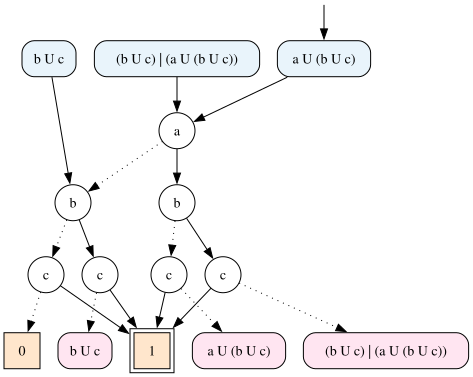

In [6]:
spot.ltlf_to_mtdfa("a U b U c", False, False)



Different LTLf formulas can have the same MTBDD representation. Above, we can see that $tr(a \mathbin{\mathsf{U}} (b \mathbin{\mathsf{U}} c))=tr((b \mathbin{\mathsf{U}} c) \lor a \mathbin{\mathsf{U}} (b \mathbin{\mathsf{U}} c))$.

Since the successors of these states are identical, it makes sense to fuse them.  This is actually what `ltlf_to_mtdfa()` does by default.

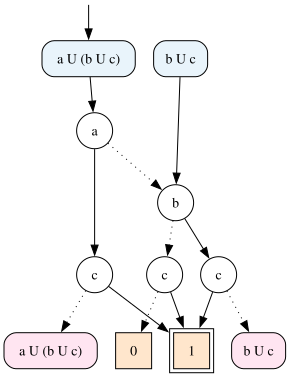

In [7]:
aut1 = spot.ltlf_to_mtdfa("a U b U c")
aut1

When fusing states, we must be cautious about the acceptance of these states.

Here is an example where this is clearly visible:

In [8]:
display_inline(spot.ltlf_to_mtdfa("GFa", False, False), spot.ltlf_to_mtdfa("GFa"))

Here, $(\mathop{\mathsf{F}}a)\land (\mathop{\mathsf{G}}\mathop{\mathsf{F}}a)$ and $\mathop{\mathsf{G}}\mathop{\mathsf{F}}a$ are equivalent, so the algorithm simply remembers the first formula it has seen.  Distinguishing the acceptance of the terminal nodes is not a problem.

**Implementation details:** A MTDFA is represented using two arrays:
- `formula names[n];`
- `bdd states[n];`


The MTBDD stored in `states[i]` encodes the outgoing edges of state `i`.  State 0 is always the initial state.    The terminal in those MTBDDs store integers of the form `2j+a` were `j` is the index of the destination state, and `a` is a boolean indicating whether that destination is accepting.  The `names` array is purely cosmetic: `names[i]` is the LTLf formula associated to state `i`, it can be used for rendering (`names` can be empty if one does not want to label the states).   

Automaton `aut1` above automaton has `n=2` roots for `a U b U c` and `b U c`, but one will usually want to consider `1` as a state.  The state for formula `1` is not stored, because it is always encoded as *true*.  (People who prefer to work with complete DFAs, might want to consider `0` as a state too.)  The `mtdfa` class has two methods to return its size: `num_roots()` counts the number of roots stored in the DFA (i.e., the size of the `states` and `names` array), and `num_states()` adds one to `num_roots()` if any root can reach `true`.

In [9]:
print(aut1.num_roots(), aut1.num_states())

2 3


# Propositional equivalence

The approach for building a MTDFA described above does not always terminate.

For instance consider $\varphi_1=(\mathop{\mathsf{G}}a) \mathbin{\mathsf{W}} (\mathop{\mathsf{G}}b)$.  The MTBDD constructed by $tr(\varphi)$ will contain a path labeled $a\land b$ with destination $term(\varphi_2, \top)$ where $\varphi_2=(\mathop{\mathsf{G}}b) \lor ((\mathop{\mathsf{G}}a) \land \varphi_1)$.  The formula MTBDD for $tr(\varphi_2)$ will in turn contain a path labeled by $a\land b$ with destination $term(\varphi_3, \top)$ where $\varphi_3=(\mathop{\mathsf{G}}b) \lor ((\mathop{\mathsf{G}}a) \land ((\mathop{\mathsf{G}}b) \lor ((\mathop{\mathsf{G}}a) \land \varphi_1)))$.  The series could continue indefinitely like this adding new terms as it progress.

To avoid this, we say that two LTLf formulas are propositionally equivalent iff, when we interpret their maximal subformulas starting with a temporal operator as if they were propositions, the two formulas are equivalent.
For instance formulas $\varphi_2$ and $\varphi_3$ are propositionally equivalent, because if we replace $\mathop{\mathsf{G}}a$, $\mathop{\mathsf{G}}b$, and $\varphi_1$ by the propositions $p_1$, $p_2$, and $p_3$ (respectively), we have:

$$
\begin{aligned}
  \varphi_2 &= p_2 \lor (p_1 \land p_3) \\
  \varphi_3 &= p_2 \lor (p_1 \land (p_2 \lor (p_1 \land p_3))) = p_2 \lor (p_1 \land p_3)
\end{aligned}
$$

The equivalence between these two Boolean formulas can easily be established by encoding them in BDDs.

The implementation keeps track of one BDD representing the "propositional representation" of each LTLf used in a terminal, and everytime it attempts to create $term(g,b)$, it will replace it by $term(f,b)$ if a formula $f$ propositionally equivalent to $g$ has already been seen.

Doing so ensure termination, because the formula we translate has a finite number $m$ of subformulas, and the set of Boolean combinations of those formulas has only $2^{2^m}$ propositionally-equivalent classes. 

**Aside:** Implementing this wasn't fun at all, because new terminals are created by a callback function called deep into the `apply` recursion.  Propositional equivalence has to be checked inside that recursion, but it also require running other BDD operations and creating new BDD variables...  So BuDDy had to learn how to run a BDD operation from within another BDD operation, and how to introduce new variables during a BDD operation.

In [10]:
# The `ltlf_translator` class (which provide the machinery used by the
# ltlf_to_mtdfa() function) has a propeq_representative().  That function
# keep tracks of all function on which it is applied, and will return
# the first such function that is equivalent to its argument.
tmp = spot.ltlf_translator(spot._bdd_dict)
display(tmp.propeq_representative("Ga W Gb"))
display(tmp.propeq_representative("Gb | (Ga & (Ga W Gb))"))
display(tmp.propeq_representative("Gb | (Ga & (Gb | (Ga & (Ga W Gb))))"))
del tmp

spot.formula("Ga W Gb")

spot.formula("Gb | (Ga & (Ga W Gb))")

spot.formula("Gb | (Ga & (Ga W Gb))")

# Simplifying terminals

In an earlier example, we have seen that the translation of $\mathop{\mathsf{G}}\mathop{\mathsf{F}}a$ produces two different states labeled by $\mathop{\mathsf{G}}\mathop{\mathsf{F}}a$ and $\mathop{\mathsf{F}}a\land\mathop{\mathsf{G}}\mathop{\mathsf{a}}$.  These two states have exactly the same MTBDD encoding, so that can be detected and fixed in a second pass after the translation.  The only problem is that we did have to translate both formulas into MTBDDs.

The situation can get a lot worse: $\bigwedge_{i=1}^n \mathop{\mathsf{G}}\mathop{\mathsf{F}}p_i$ will create $2^n$ different terminals, but all these terminal are labeled by formulas that translate identically.

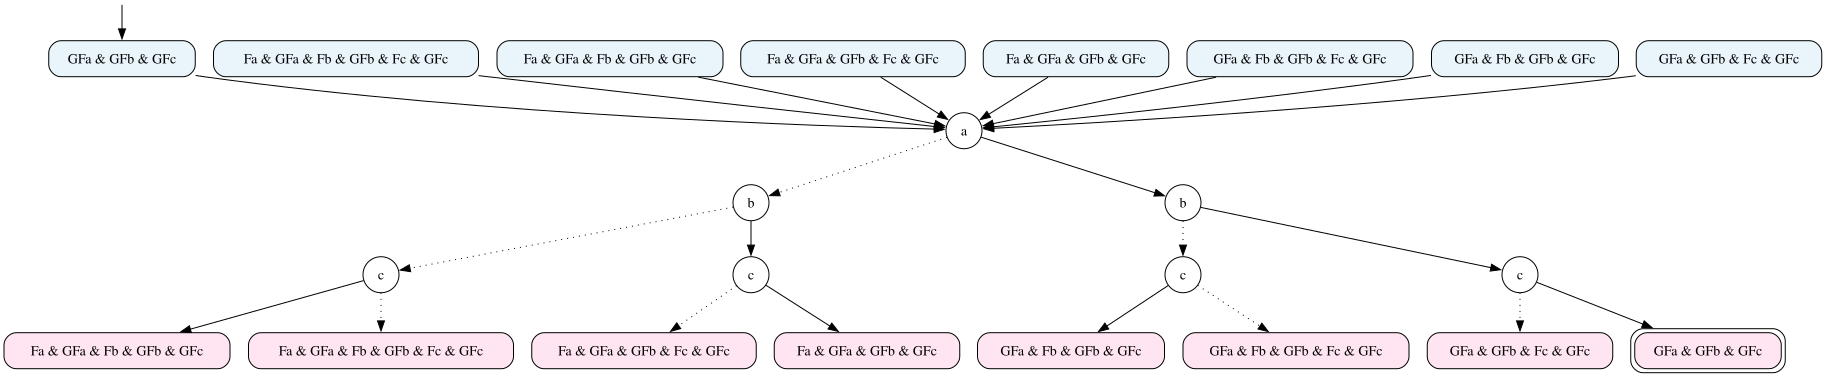

In [11]:
spot.ltlf_to_mtdfa("GFa & GFb & GFc", False, False)

To avoid that, the `propeq_representative` function, that is already applied to each terminal formula to detect if it is propositionally equivalent to a previous formula, also implements the following cheap simplifications:

$$
\begin{aligned}
      (\alpha \mathbin{\mathsf{U}} \beta)\lor \beta &\equiv \alpha \mathbin{\mathsf{U}} \beta \\
      (\alpha \mathbin{\mathsf{W}} \beta)\lor \beta &\equiv \alpha \mathbin{\mathsf{W}} \beta \\
      (\alpha \mathbin{\mathsf{M}} \beta)\land \beta &\equiv \alpha \mathbin{\mathsf{M}} \beta \\
      (\alpha \mathbin{\mathsf{R}} \beta)\land \beta &\equiv \alpha \mathbin{\mathsf{R}} \beta \\
      (\mathop{\mathsf{F}}\beta) \lor \beta &\equiv \mathop{\mathsf{F}}\beta \\
      (\mathop{\mathsf{G}}\beta) \land \beta &\equiv \mathop{\mathsf{G}}\beta
\end{aligned}
$$

There is one such rule for each temporal operator, for a pattern likely to occur in the output of $tr(\cdot)$.

In [12]:
spot.ltlf_translator(spot._bdd_dict).propeq_representative("GFa & GFb & GFc & Fa & Fb")

spot.formula("GFa & GFb & GFc")

In practice, for the $\bigwedge_{i=1}^n \mathop{\mathsf{G}}\mathop{\mathsf{F}}p_i$ formula mentionned above, those rules reduce all terminals to the input formula, causing a single state to be created.  And there are no identical state to merges aferwards.

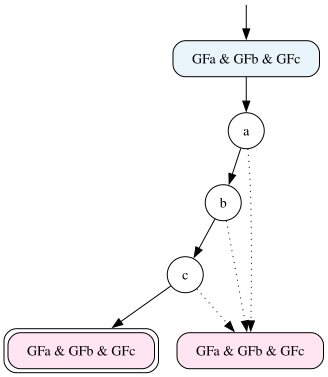

In [13]:
spot.ltlf_to_mtdfa("GFa & GFb & GFc",
                   False,   # fusing states with identical MTBDD is disabled
                   True)    # simplification of terminal formulas is enabled

# Detecting empty or universal translations

If the result of the translation has no accepting terminal (including true), or if it has no rejecting terminal (including false), then the formula is equivalent to true or false, and the automaton can be simplified to have a single state.

This simplification is enabled by default.  Here is an example when we disable it:

In [14]:
f = "!i1 & F(o1 & X[!]!o1 & (!o2 | (!o0 & !o1) | Go1 | (o0 & !o2 & X[!]!o0) | (!o0 & (!i0 | !i1) & X[!]!o0) | (!o1 & (i0 | !i1) & X[!]!o1) | (i0 & Go0))) & G(i1 | o2 | X[!]!i1) & G(!i1 | F!i1) & G(!o2 | X[!]i1)"
spot.ltlf_to_mtdfa(f, True, True, False).show(labels=False)

By default, the translation will build the above, realize it has no accepting terminal, and therefore return a "false" automaton instead.   

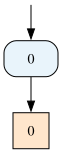

In [15]:
spot.ltlf_to_mtdfa(f)

# Conversion from MTDFA to TwA

TwA is the standard data-structure of Spot used to represent ω-automata.  
Since Spot has no class for representing DFA explicitly, this conversion is just a hack to allow a more traditional representation where we just ignore the acceptance condition.

The conversion to transition-based acceptance is straightforward: each root of the MTBDD corresponds to a state, and each path from a root to a terminal corresponds to a transition, and that transition is accepting iff the terminal is odd.  Paths going to the *true* BDD constant become transitions leading to an accepting sink.

With transition-based DFA, a word is accepted if its last letter was read by a transition marked with a ⓿.

The conversion to state-based acceptance is not more difficult: the acceptance is simply pushed onto the destination state.

Below, the `as_twa()` returns a transition-based automaton by default.  `as_twa(True)` asks for a state-based output.

In [16]:
display_inline(aut1.as_twa(), aut1.as_twa(True))

In [17]:
aut2 = spot.ltlf_to_mtdfa("GFa")
display_inline(aut2.as_twa(), aut2.as_twa(True))

# More examples

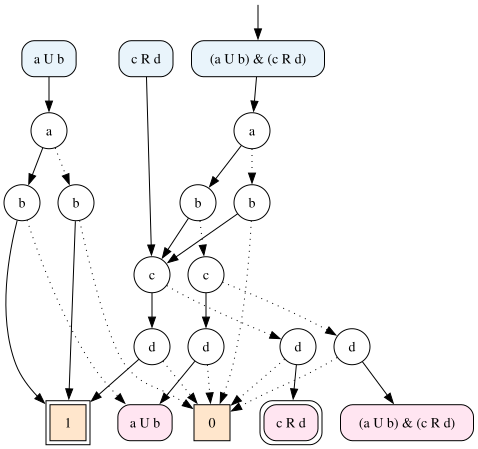

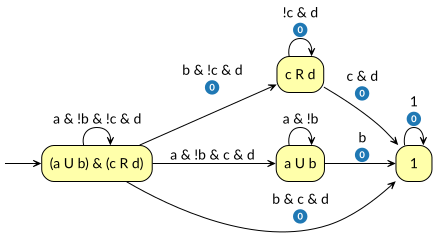

In [18]:
a1 = spot.ltlf_to_mtdfa("(a U b) & (c R d)")
display(a1, a1.as_twa())

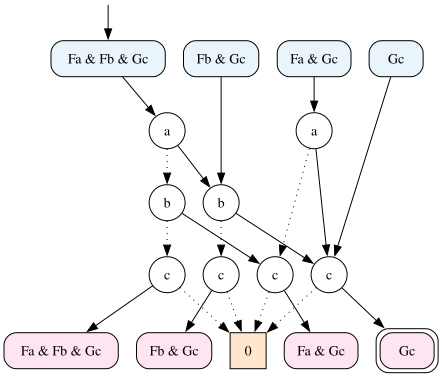

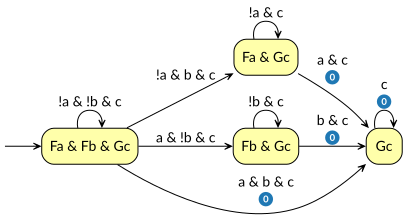

In [19]:
a2 = spot.ltlf_to_mtdfa("Fa & Fb & Gc")
display(a2, a2.as_twa())

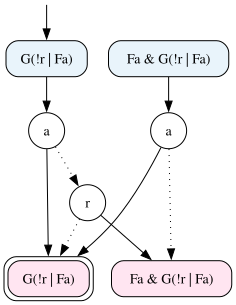

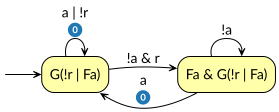

In [20]:
a3 = spot.ltlf_to_mtdfa("G(!r | Fa)")
display(a3, a3.as_twa())

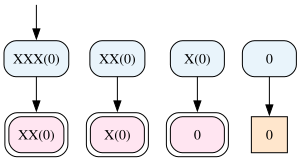

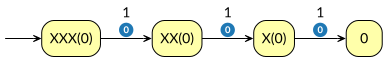

In [21]:
a4 = spot.ltlf_to_mtdfa("XXX(0)")
display(a4, a4.as_twa())

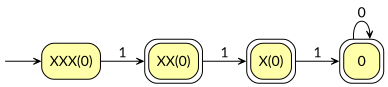

In [22]:
# because Spot only support transition-based acceptance internally,
# it has to add a false self-loop whenever he needs to emulate
# state-based acceptance on a state without successor.
display(a4.as_twa(True))

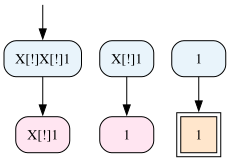

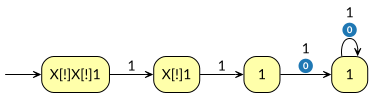

In [23]:
a5 = spot.ltlf_to_mtdfa("X[!]X[!]1")
display(a5, a5.as_twa())

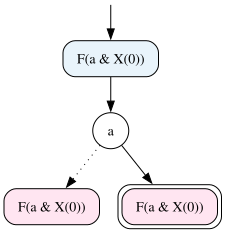

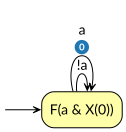

In [24]:
# The last step has to match "a".  This is equivalent to GFa or FGa in LTLf.
a6 = spot.ltlf_to_mtdfa("F(a & X(0))")
display(a6, a6.as_twa())

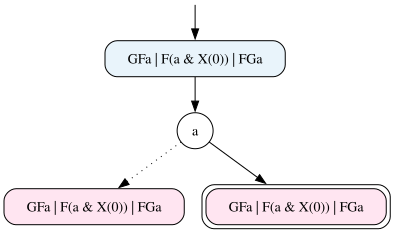

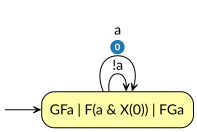

In [25]:
# same as above
a7 = spot.ltlf_to_mtdfa("F(a & X(0)) | GFa | FGa")
display(a7, a7.as_twa())

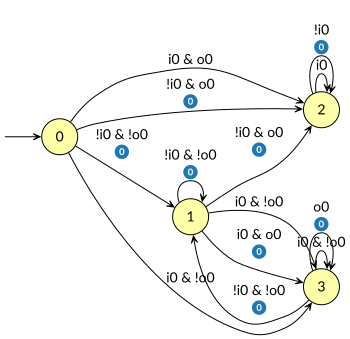

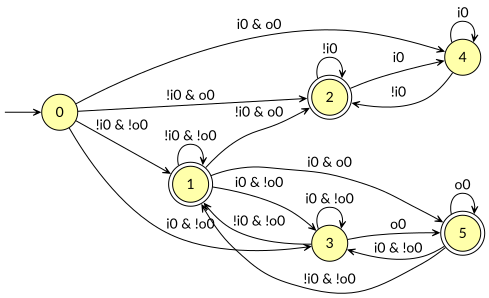

In [26]:
# lily09 -- without labels because formulas are too long (hover over the nodes to see them)
a8 = spot.ltlf_to_mtdfa("GFi0 -> (!o0 & G(!o0 -> ((!o0 U i0) & (i0 -> Fo0))) & GFo0)")
display(a8.show(labels=False), a8.as_twa(False, False), a8.as_twa(True, False))

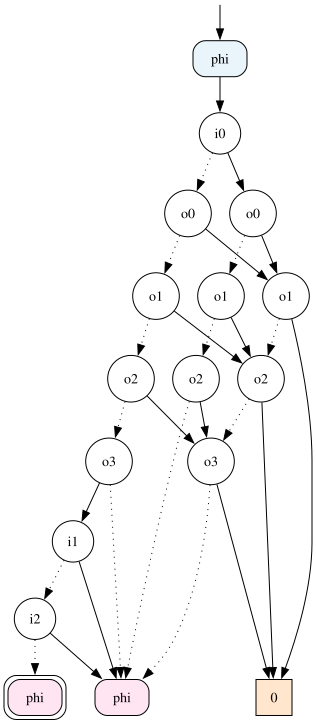

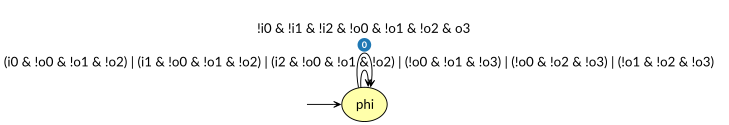

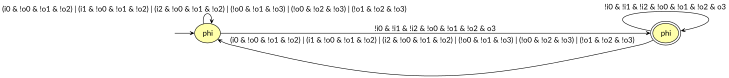

In [27]:
# lily18 -- without labels because formulas are too long
phi = "G(!(o0 & o1) & !(o0 & o2) & !(o0 & o3) & !(o1 & o2) & !(o1 & o3) & !(o2 & o3)) & (GFi0 -> GFo0) & (GFi1 -> GFo1) & (GFi2 -> GFo2) & GFo3"
a9 = spot.ltlf_to_mtdfa(phi)
a9.names[0] = spot.formula("phi") # Rename the formula for cosmetics
display(a9, a9.as_twa(), a9.as_twa(True))

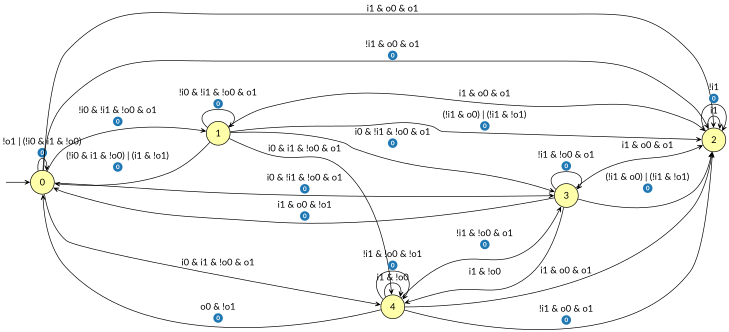

In [28]:
# lily19 -- without labels because formulas are too long  (hover on the states to read them)
f = "GFi1 -> G(o1 -> (!(o0 & o1) & (o1 U i1) & (o0 -> (o0 U i1)) & (i0 -> Fo0) & Fo1))"
a11 = spot.ltlf_to_mtdfa(f)
display(a11.show(labels=False), a11.as_twa(False, False))

On the above example, we can see how transition-based acceptance can save three states (copies of 0, 2, and 4).  Here is the state-based version for comparison.

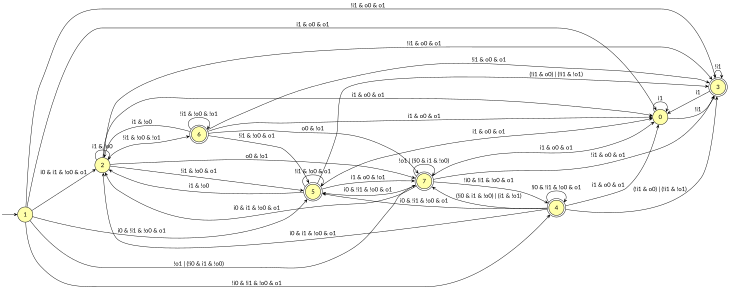

In [29]:
spot.translate(f, "finite", "deterministic")

# DFA Minimization

The MTBDD-based DFA allows a very simple implementation of minimization by partition refinement, similar to what is used in Mona.

  1. Assume all terminal belong to the same class, numbered 0.
  2. Rewrite all MTBDDs by relabeling each terminal by its class number (preserving the acceptance bit)
  3. Group all states in new classes according to their new BDD representation, giving each class a new number.
  4. Loop to 2 until the number of classes is stable.

For the purpose of the above algorithm, *false*, and *true* should treated as terminals (i.e., assigned a class and rewritten).  The actual implementation then performs a final pass on the result to put *false* and *true* back.

Let's find some formulas on which this minimization is effective by trying the examples from [Lily](http://www.ist.tugraz.at/staff/jobstmann/lily/).  (These are LTL examples, but we interpret them as LTLf here.)

In [30]:
import spot.gen as sg
from timeit import default_timer as timer

In [31]:
print("           states                    time          ")
print("       -------------     --------------------------")
print("       DFA  min  ref        DFA  DFA+min        ref")
for i, f in enumerate(sg.ltl_patterns(sg.LTL_LILY_PATTERNS)):
    t1 = timer()
    dfa = spot.ltlf_to_mtdfa(f)
    t1b = timer()
    mindfa = spot.minimize_mtdfa(dfa)
    t2 = timer()
    n1, n2 = dfa.num_states(), mindfa.num_states()
    mark = ">" if n1 > n2 else " "
    t3 = timer()
    ref = spot.translate(f, "finite", "deterministic", xargs="tls-impl=0")
    t4 = timer()
    refsz = ref.num_states()
    t1b -= t1
    t2 -= t1
    t4 -= t3
    tmark = '='
    if t4 > t2: tmark = "<"
    elif t4 < t2: tmark = ">"

    # While we are there, let's control that mindfa ≡ ref.
    # We can do that by checking the emptiness of mindfa XOR ref.
    assert spot.product_xor(mindfa, spot.twadfa_to_mtdfa(ref)).is_empty()

    print(f"lily{i+1:<3} {n1:2} {mark} {n2:2}   {refsz:2}   {t1b * 1000:6.2f}ms {t2 * 1000:6.2f}ms {tmark} {t4 * 1000:6.2f}ms")

           states                    time          
       -------------     --------------------------
       DFA  min  ref        DFA  DFA+min        ref
lily1    6    6    7     0.31ms   0.34ms <   0.53ms
lily2    9    9   12     0.14ms   0.17ms <   0.94ms
lily3   13   13   14     0.22ms   0.26ms <   1.37ms
lily4   21   21   23     0.21ms   0.25ms <   1.55ms
lily5   16   16   19     0.16ms   0.19ms <   1.12ms
lily6   25   25   30     0.15ms   0.19ms <   2.11ms
lily7    8    8    9     0.08ms   0.10ms <   0.58ms
lily8    1    1    2     0.05ms   0.06ms <   0.20ms
lily9    4    4    6     0.05ms   0.06ms <   0.24ms
lily10   4    4    7     0.05ms   0.06ms <   0.45ms
lily11   4    4    4     0.07ms   0.08ms <   0.30ms
lily12   8 >  6    7     0.07ms   0.08ms <   0.38ms
lily13   2    2    2     0.04ms   0.05ms <   0.17ms
lily14   1    1    2     0.05ms   0.06ms <   0.91ms
lily15   8    8    9     0.08ms   0.09ms <   0.51ms
lily16  22   22   23     0.20ms   0.23ms <   1.41ms
lily17   1  

The columns labeled DFA refer to the MTDFA construction, and show the number of states and time of the construction.

The columns labeled min refer to the minimized MTDFA; the time includes the time of the translation.

The "ref" column refers to the historical LTLf->LTL->DBA->DFA pipeline, that produces a state-based minimal DFA.  (Note that this pipeline performs some LTL simplification on the LTL formula prior to translation to DBA. The LTLf->MTDBA construction does not do any such simplification. The `tls-impl=0` option disables implication-based simplifications, to save some time.)

Both `min` and `ref` are minimal, but the former uses transition-based acceptance while the latter uses state-based acceptance.

Here is the only instance where minimization is useful:

In [32]:
def showlily(n, labels=False):
    f = sg.ltl_pattern(sg.LTL_LILY_PATTERNS, n)
    print("-- before minimization --\n")
    aut = spot.ltlf_to_mtdfa(f)
    display(aut.show(labels=labels), aut.as_twa(False, labels))
    print("-- after minimization --\n")
    minaut = spot.minimize_mtdfa(aut)
    display(minaut.show(labels=labels), minaut.as_twa(False, labels))

-- before minimization --



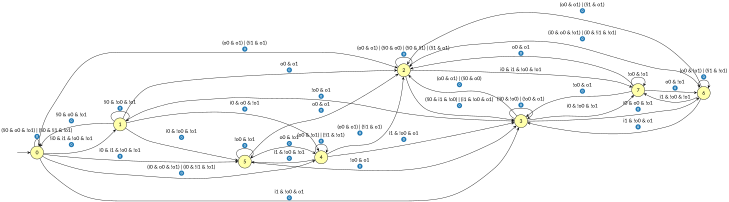

-- after minimization --



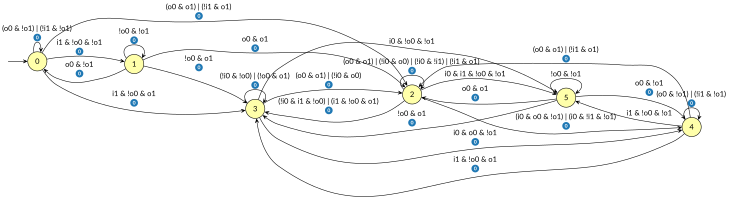

In [33]:
showlily(12)

# Minimal MTDFA does not imply minimal state-based DFA

An MTDFA is transition-based in nature, because the acceptance can be different on each path from a root.  

Although there is an easy interpretation of the MTDFA as a state-based DFA, the following shows that the state-based automaton one obtains from a minimial MTDFA is not necessarily minimal itself.  Here, the minimial transition-based DFA `autA`, obtained via this approach, has 8 states.   The state-based automaton obtained from that automata, `autB`, has 12 states.  But the minimial state-based DFA computed using the historical LTLf->LTL->DBA->DFA pipeline has 9 states.

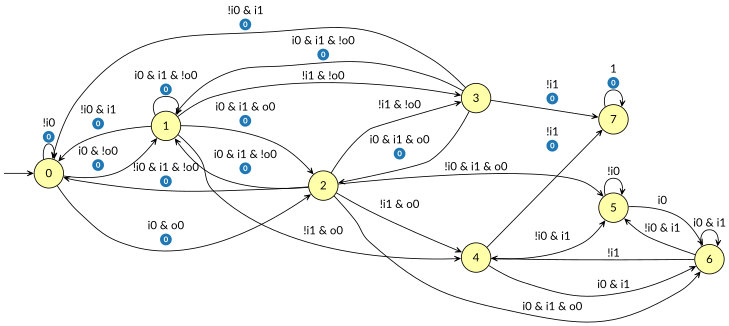

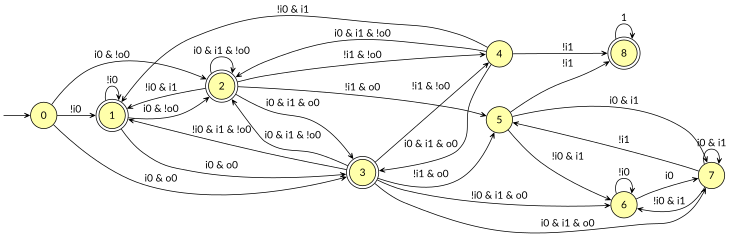

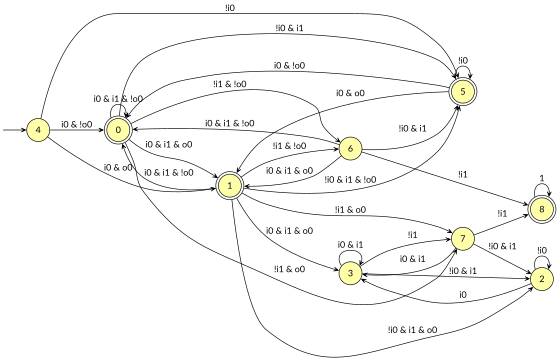

In [34]:
lily07 = "G(i0->X(i1|Xi1))->G(i0->(X(!o0 U i1)&(o0->X!o0)&(i2->(i0|o0|X(i0|o0|X(i0|o0|X(i0|o0)))))))"
l07 = spot.ltlf_to_mtdfa(lily07)
l07 = spot.minimize_mtdfa(l07)
# Get rids of formula labels, as they are too large
l07.names.clear()
autA = l07.as_twa(False)
autB = l07.as_twa(True)
autC = spot.translate(lily07, "finite", "deterministic")
# Ensure equivalence between l07 and aut.
assert spot.product_xor(l07, spot.twadfa_to_mtdfa(autC)).is_empty()
display(autA, autB, autC)

# Examples that caused problems to the minimization at some point

Let's keep these examples so that the notebook can serve as a test suite.

This large automaton reduces to false because it has no accepting terminals.  `ltlf_to_mtdfa()` will detect that and return false already (unless we disable the optimization as done below), but the minimization should also achieve that.

In [35]:
f = "!i1 & F(o1 & X[!]!o1 & (!o2 | (!o0 & !o1) | Go1 | (o0 & !o2 & X[!]!o0) | (!o0 & (!i0 | !i1) & X[!]!o0) | (!o1 & (i0 | !i1) & X[!]!o1) | (i0 & Go0))) & G(i1 | o2 | X[!]!i1) & G(!i1 | F!i1) & G(!o2 | X[!]i1)"
dfa = spot.ltlf_to_mtdfa(f, True, True, False)
display(dfa.show(labels=False))
spot.minimize_mtdfa(dfa).show(labels=False)

Because the minimization has to turn constants false and true to terminals, it is a bit tricky to turn the terminal back into false/true especially in automata were "accepting false" or "rejecting true" are used, because these two have to be kept as terms.  The following translations, where minimization should have no effect, used to highlight issues with previous implementations of the minimization.

In [36]:
a = spot.ltlf_to_mtdfa("X[!](1) | Ga")
display_inline(a, spot.minimize_mtdfa(a))

In [37]:
a = spot.ltlf_to_mtdfa("X[!](b & X[!](1)) | Ga | X[!](c & X[!]X(0))")
display_inline(a.show(labels=True), spot.minimize_mtdfa(a))

In [38]:
a = spot.ltlf_to_mtdfa("X(0) | Ga")
display_inline(a.show(labels=True), spot.minimize_mtdfa(a))

# Boolean operations on MTDFAs

The cross-product of two MTDFAs can be done combining the initial MTBDDs of the two MTDFAs in such a way that the terminal of the product represent pairs of states of the original formulas.  

The combination function used can implement any Boolean operation.  In practice the Boolean operation just changes the way the acceptence of the new terminal is defined.  Using $term(s_\ell,b_\ell)$ represent a terminal for state $s_\ell$ in the left automaton, and $term(s_r,b_r)$ is a terminal in the right automaton, then for a Boolean operator $\odot$ we combine MTBDD using the rule $term(s_\ell,b_\ell)\odot term(s_r,b_r) = term((s_\ell,s_r),b_\ell \odot b_r)$.

Once we have computed MTBDDs for all pairs $(s_\ell,s_r)$ appearing in terminals that can be transitively reached this way, we can compute the names of all the states associated to those pairs.

The following Boolean functions are available:
  - `product()`  implements $\land$
  - `product_or()`  implements $\lor$
  - `product_xor()`  implements $\oplus$
  - `product_xnor()`  implements $\leftrightarrow$
  - `product_implies()`  implements $\rightarrow$

Except for `product_implies`, the other functions are already defined for the `twa` class.

Let's build three base MTDFAs so that we can combine them.

In [39]:
gfa = spot.ltlf_to_mtdfa("GFa")
aub = spot.ltlf_to_mtdfa("a U b")
xxc = spot.ltlf_to_mtdfa("XXc")
display_inline(gfa, aub, xxc)

In [40]:
display_inline(spot.product(gfa, aub), spot.product_or(gfa, aub))

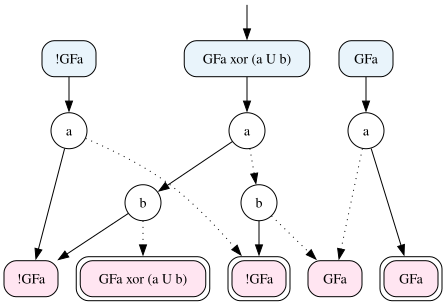

In [41]:
spot.product_xor(gfa, aub)

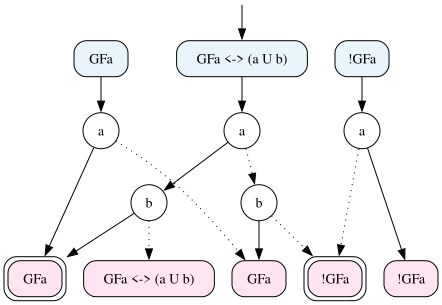

In [42]:
spot.product_xnor(gfa, aub)

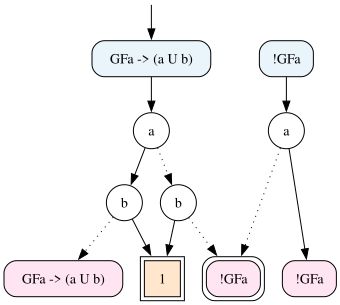

In [43]:
spot.product_implies(gfa, aub)

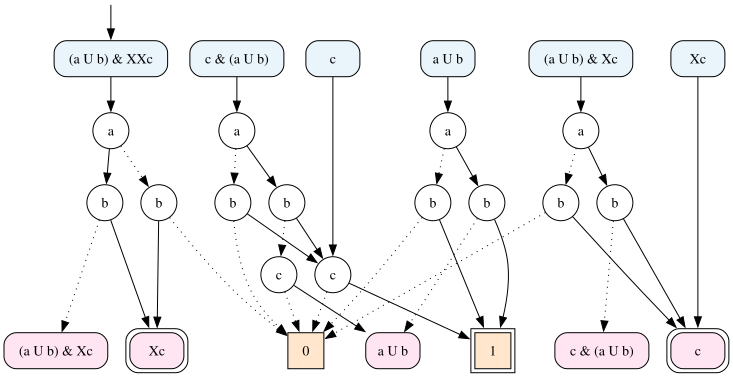

In [44]:
spot.product(aub, xxc)

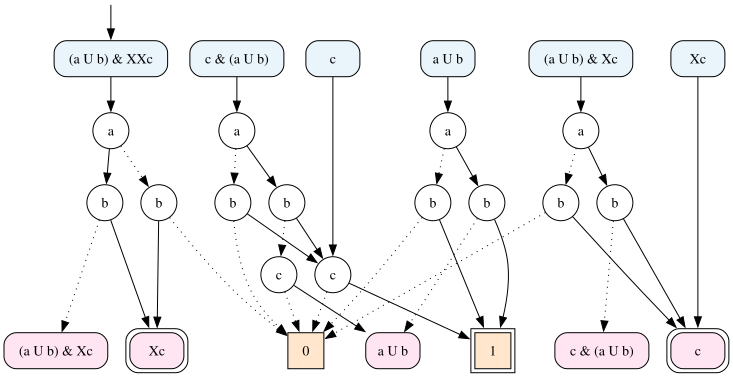

In [45]:
# The above (obtained by product) is similar to what we get by direct translation
spot.ltlf_to_mtdfa("(a U b) & XXc")

Additionally, `complement()` does what's expected: accepting terminals become non-accepting and vice-versa.  Formula labels are also negated for looks.

In [46]:
display_inline(aub, spot.complement(aub))

# Converting from TwA to MTDFA

The helper function `spot.twadfa_to_mtdfa()` can be used to convert a TwA representing a DFA into MTDFA.  It should work if the input TwA is state-based (as in next cell), or transition-based (three cells down).

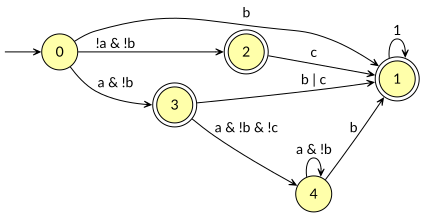

In [47]:
a = spot.translate("(a U b) | Xc", "finite", "deterministic")
a

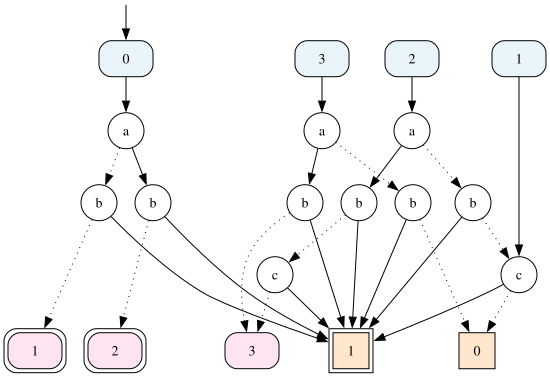

In [48]:
a2 = spot.twadfa_to_mtdfa(a)
a2

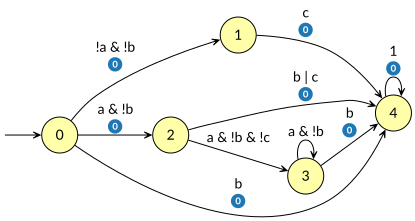

In [49]:
a3 = a2.as_twa(False, False)
a3

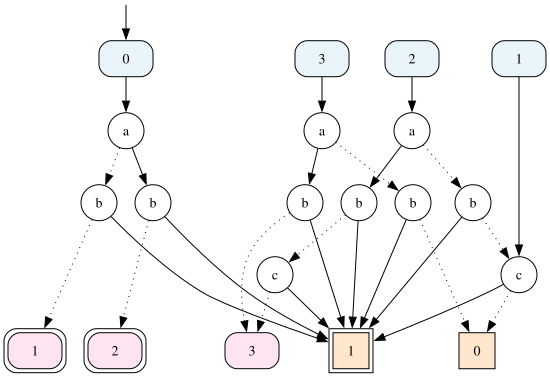

In [50]:
a4 = spot.twadfa_to_mtdfa(a3)
a4

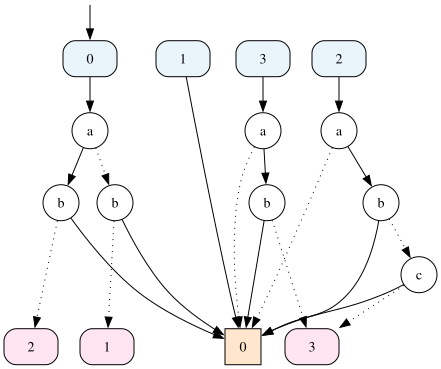

True


In [51]:
# We can check that a2 and a4 are equivalent by checking the emptiness of a2 XOR a4.
p = spot.product_xor(a2, a4)
display(p)
print(p.is_empty())

# Compositional translation

`ltlf_to_mtdfa()` translate an entire formula at once, using the $tr(\cdot)$ function defined above.  The resulting MTDFA can then be minimized if desired.

`ltlf_to_mtdfa_compose()` implements a compositional approach in which maximal subformulas that starts with a temporal operator are first translated and minimized separately, and the resulting minimial MTDFA are then combined recursively according to the Boolean operators that connect those formula.

For instance in the formula $\lnot\mathop{\mathsf{G}}(i_1\rightarrow \mathop{\mathsf{F}}o)\land \lnot\mathop{\mathsf{G}}(i_2\rightarrow \mathop{\mathsf{F}}o)$, `ltlf_to_mtdfa_compose()` will first call
`ltlf_to_mtdfa()` to translate $\mathop{\mathsf{G}}(i_1\rightarrow \mathop{\mathsf{F}}o)$ and $\mathop{\mathsf{G}}(i_2\rightarrow \mathop{\mathsf{F}}o)$ separately.  Then those two automata will be minimized.  Then they will be both complemented and combined with `product()`, and finially the result of the product will be minimized again.  Minimizing at every step like this can help keep the automaton small, and avoid the quadratic cost of running minimization on a very large automaton at the end of the translation.

In practice, the compositional approach works very well on benchmarks that have been built in a compositional way, for instance conjunctions of random formulas.

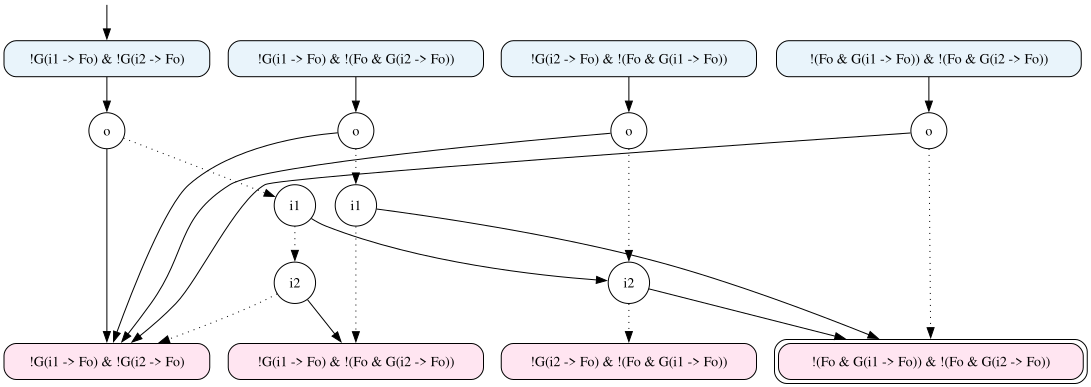

In [52]:
f = spot.formula("!G(i1 -> Fo) & !G(i2 -> Fo)")
a = spot.ltlf_to_mtdfa_compose(f); a

In this case, the direct translation produces the same result:

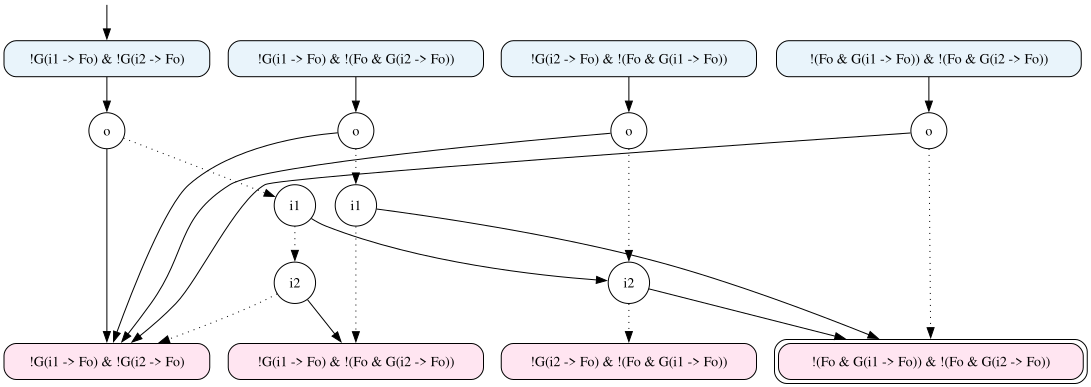

In [53]:
spot.ltlf_to_mtdfa(f)

# Game interpretation

Let's now assume that a subset $C$ of the atomic proposition represent *controllable* variables.   The complement of these variables are the *uncontrollable* variables.  We assume that the environement is setting the uncontrollable variables for the current step, and that we are looking for a controller that will set the controllable variables in such a way that the automaton eventually reaches an accepting terminal.

There are two semantics we can work with: 

- with **Mealy**'s semantics, the controllable variables can be set depending on the uncontrollable variables.  In other words, the environment sets the uncontrollable variables, and the controller reacts to that by setting the output variables.  In a game set up, the environment plays before the controller.
- with **Moore**'s semantics, the controller sets the controllable variables based *only* on the current state, and the environment can decide about the uncontrolled variables based on the value of the controlled one.  In a game set up, the environment plays after the controller.

To interpret our MTDFA as a game, we will simply order the variables of the first player above those of the second player (according to the selected semantics).  

We can do so by using a fresh `bdd_dict` in which we pre-register the atomic propositions we want to see at the top of the MTDFA.
For cosmetics, calling `set_controllable_variables` on the automaton will render controllable variables as diamond nodes.

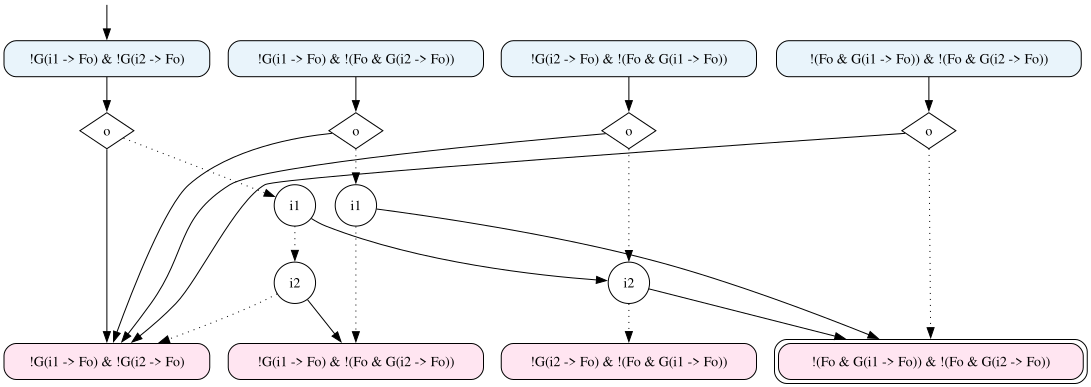

In [54]:

with spot.bdd_dict_preorder("o") as d:
    a_moore = spot.ltlf_to_mtdfa_compose("!G(i1 -> Fo) & !G(i2 -> Fo)", dict=d)
    a_moore.set_controllable_variables(["o"])
display(a_moore)

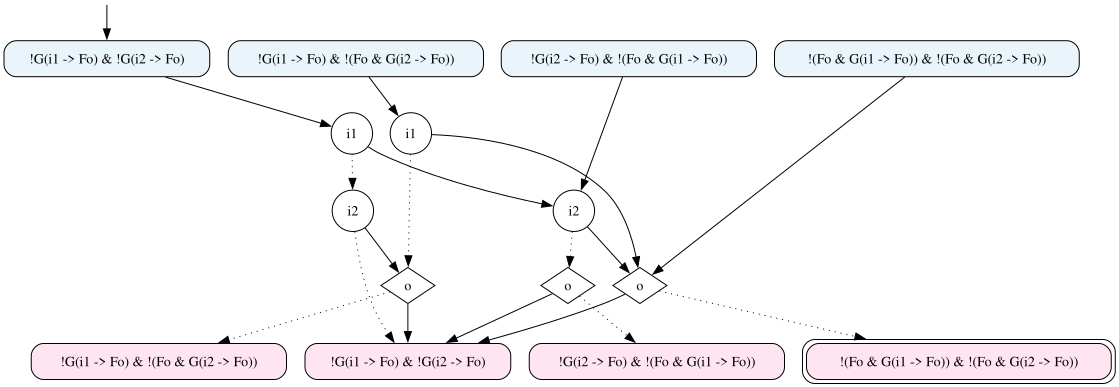

In [55]:
with spot.bdd_dict_preorder("i1", "i2") as d:
    a_mealy = spot.ltlf_to_mtdfa_compose("!G(i1 -> Fo) & !G(i2 -> Fo)", dict=d)
    a_mealy.set_controllable_variables(["o"])
display(a_mealy)

The game interpretations of those MTDFA is that the controller plays the controllable variables and wins if it manages to steer the automaton towards an accepting terminal.  The environments plays the uncontrollable variables and wins if he manages to avoid accepting terminals.  We solve those games from the point of view of the controller, i.e., we say that the game is winning if the controller has a strategy to force the automaton to reach an accepting terminal, regardless of what the environment plays.

We will say that a *terminal is winning* if it is accepting, or if it represents a *winning* state.  A *state is winning* if it has an assignment of controllable variables to force the automaton to eventually reach a winning terminal regardless of the value of uncontrollable variables.  Please read the previous sentence twice, because this actually hides some transition-based semantics: reaching an accepting terminal is winning for the controller, but it does not imply that the state corresponding to that terminal is also winning for the controller.  

(An alternative way to look at the game without transition-based semantics is to assume that accepting terminals correspond to game vertices without successors.  The game can only continue after non-accepting terminals.)

In any case, what we described is a *reachability* game.

# Different ways to solve such a game

We have two ways to solve the game **node**-based, or **state**-based.  We illustrate both here, but in practice the `node`-based approach is better: it uses slightly more memory, but always runs in linear time.

## Node-based approach

The **node**-based approach is probably the more natural, since this is how the game is presented to us: the nodes of the MTBDDs used to represent the MTDFA are the vertices of the game arena.  We assume that rejecting terminal have the corresponding MTBDD root as successor, and that accepting terminals are winning nodes for the output player.  If a diamond node N can has a winning node as successor, N can be marked as winning too.  If a round node
has only winning successors, then that node is winning as well.  If, after some iteration of those rules, we manage to determinate that the initial state is winning, then the LTLf formula was realizable.

Such a backpropagation algorithm can be executed in linear time, but it requires duplicating the graph structure to keep track of the predecessors of each node.  We can use Spot's `backprop_graph` to solve this, but it will help to read the [backprop notebook](backprop.ipynb) first, to better understand what follows.  In particular, the `backprop_graph` only keeps track of edges that will be used for backtracking.   For instance, if you connect a diamond node to a winning node, the diamond node can be marked as winning already, which means that the edge between the two nodes does not have to be kept; the `backprop_graph` will therefore ignore such unnecessary edges to save memory.  This dropping of edges might make it a bit difficult to compare the `backprop_graph` with the MTDFA it was created from.   

Here is a an example with Moore semantics:

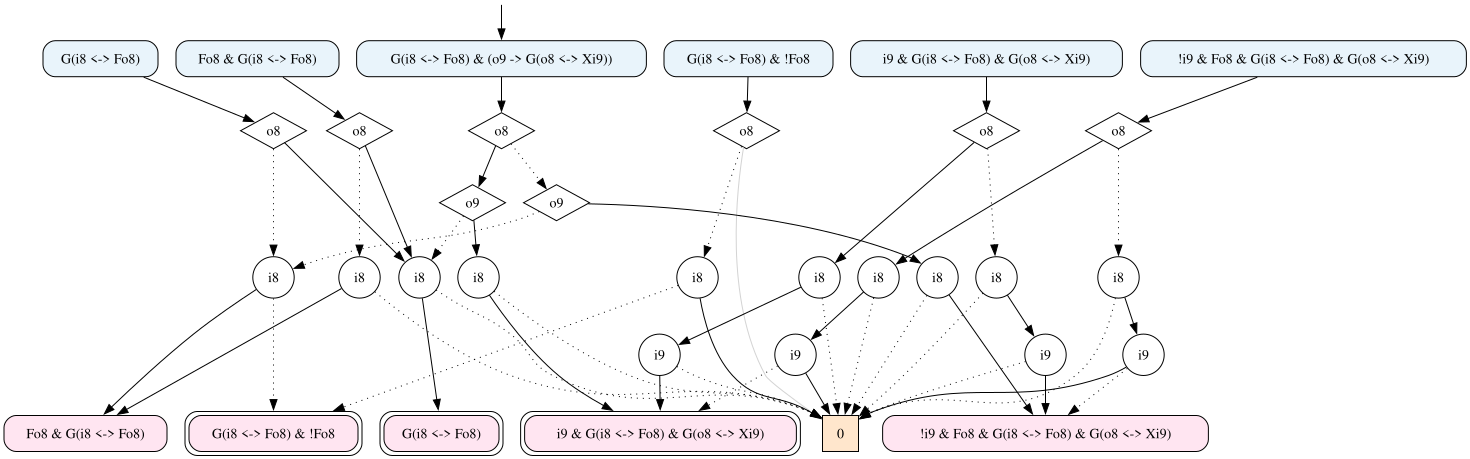

In [56]:
f = spot.formula("G(i8<->Fo8) & (o9 -> G(Xi9<->o8))")
C = ["o8", "o9"]
UC = ["i8", "i9"]

with spot.bdd_dict_preorder(*C) as d:
    a_moore = spot.ltlf_to_mtdfa_compose(f, dict=d)
    a_moore.set_controllable_variables(C)
display(a_moore)

It what follows, the nodes of the MTBDD representing each state of the MTDFA are encoded into the backprop graphs, one state (of the MTDFA) at a time. The `bddfalse` node is mapped to a losing game vertex labeled by `false`, and all accepting terminals are mapped into a winning vertex labeled by `true`.  The winning status of each game vertex is backpropapagted during the construction, and unnecessary edges are dropped.

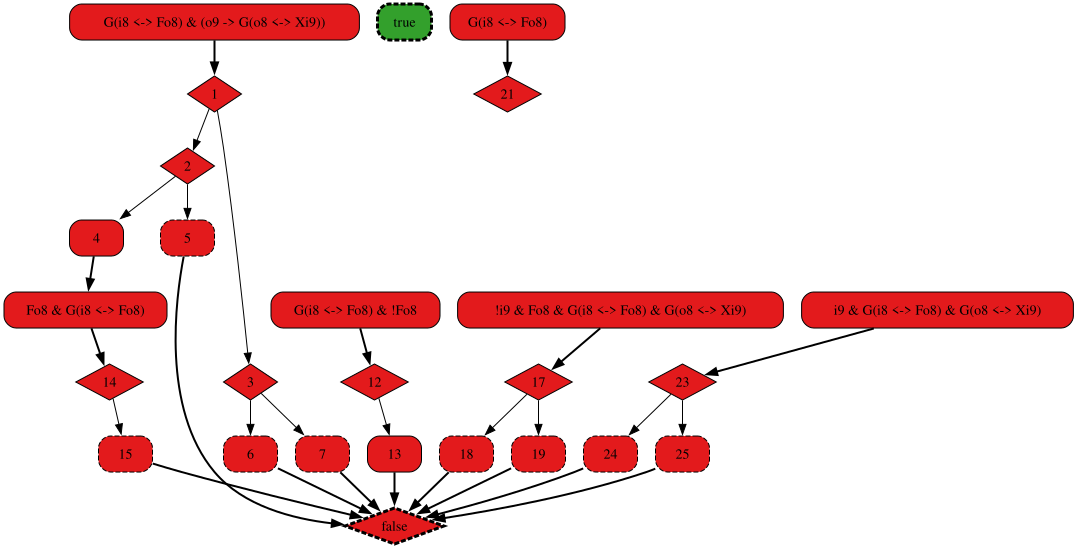

In [57]:
b = spot.mtdfa_to_backprop(a_moore, False, True)
b

The status of each state is encoded using two bits: `b.is_determined(s)` indicate whether a winner is known of state `s`.  Then `b.winner(s)` gives the winning player for state `s`.   When the state is underitermined, the winner default to `False`.

| determined | winner | meaning |
|------------|--------|---------|
| False      | False  | Player True (output) cannot force the game to reach an accepting terminal, and player False (input) cannot for the game to reach a rejecting sink  |
| True       | False  | Player False (input) can force the game to reach a rejecting sink |
| True       | True   | Player True (output) can force the game to reach an accepting terminal |

Therefore the formula is realizable iff `winner(0) == True`.

In [58]:
b.is_determined(0), b.winner(0)

(True, False)

The second argument of `mtdfa_to_backprop()` requests that the algorithms aborts as soon as the winning status of the initial state is determined.  If we enable it, you can see that the backprop graph has fewer vertices.   (The third argument of `mtdfa_to_backprop()` asks to preserves the formulas that label states.)

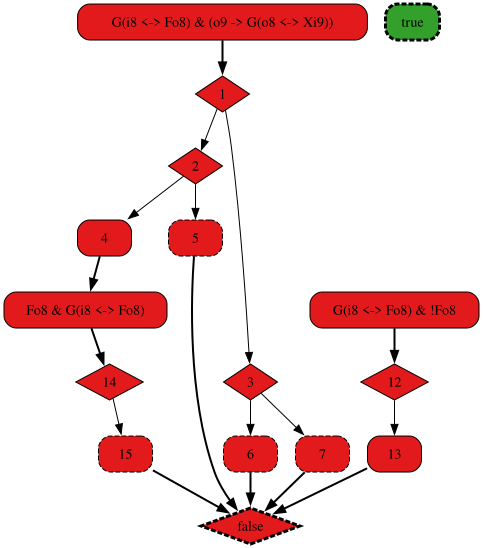

In [59]:
b = spot.mtdfa_to_backprop(a_moore, True, True)  # abort early
b

Let's do the same with Mealy semantics:

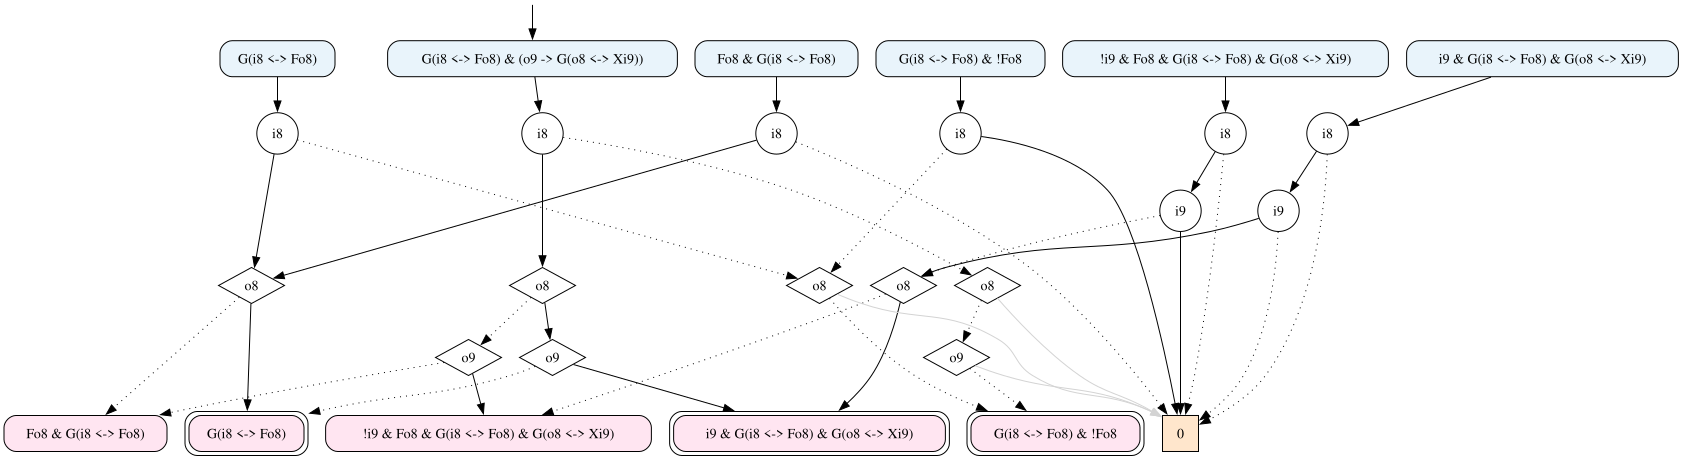

In [60]:
with spot.bdd_dict_preorder(*UC) as d:
    a_mealy = spot.ltlf_to_mtdfa_compose(f, dict=d)
    a_mealy.set_controllable_variables(C)
display(a_mealy)

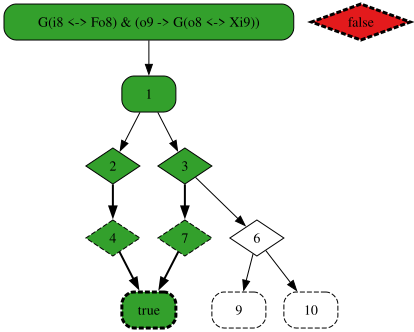

In [61]:
b = spot.mtdfa_to_backprop(a_mealy, True, True)  # abort early
b

In [62]:
b.is_determined(0), b.winner(0)

(True, True)

The process of interpreting an MTDFA as a game, solving the game, and then extracting a strategy is implemented
by `mtdfa_winning_strategy`.  A strategy is just an MTDFA where each diamond node has exactly one successor that is `bddfalse`, indicating that the strategy it always to take the other successor.  (Arrow between diamond nodes and `bddfalse` are colored in gray so we remember they should not be used.)

The second argument of `True` requests the node-based approach.  `mtdfa_winning_strategy` will "refine" the MTBDD
for each states while it is solving the game by backpropagation.  It does not waste time cleaning up the result MTDFA by removing unnecessary states.  Below you can see that the formula is realizable in one step.  By following the path from the initial state, if the environment sets i8=0, then the controller should set o8=o9=0, and if the envirnment sets i8=1, the controller should set o8=1 and o9=0.

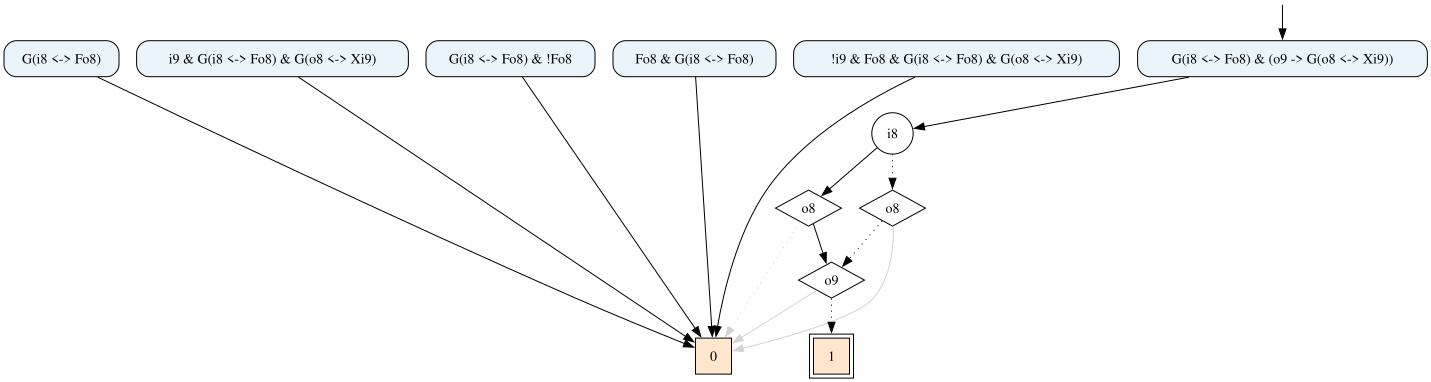

In [63]:
spot.mtdfa_winning_strategy(a_mealy, True)

When no winning strategy exists, `mtdfa_winning_strategy` returns an MTDFA with an initial state equal to `bddfalse`:

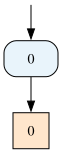

In [64]:
spot.mtdfa_winning_strategy(a_moore, True)

## The state-based approach

In the **state**-based approach to game solving, we do not keep track of the winning status of the nodes of the MTBDDs.  We just keep track of the winning status of states.

We find the set of *winning* states using a fixpoint algorithm.  Initially, all states are considered as losing.
Among those losing states we look for those for which there is an assignment of controllable variables that allow
them to forcibly reach a winning terminal.  This can be done by quantifying all variables of the MTBDD $b$ representing a state: controllable variables (in $C$) are existentially quantified, other variables are universaly quantified, and terminals are replaced by true if the are known to be winning or false otherwise.  

The following pseudo-code shows how this quantification is performed on the MTBDD for a single state, caching the results in `cache` since multiple branches of the MTBDD can share the same node.

```python
def is_winning_state(b, C, winterm, cache):
    # leaves
    if b == bddtrue: return True
    if b == bddfalse: return False
    if is_terminal(b): return winterm(b)  # is this terminal known to be winning?

    # internal nodes
    if b in cache: return cache[b]
    wlow = is_winning_state(b.low, C, winterm, cache)
    whigh = is_winning_state(b.high, C, winterm, cache)
    if b.var in C: 
        res = wlow | whigh  # ∃-quantification
    else:
        res = wlow & whigh  # ∀-quantification
    cache[b] = res
    return res
```
The function `winterm` returns True if the terminal
is accepting, or if it is going to a state that has already been found to be winning.

Since `is_winning_state` only returns `True` or `False`, it does not have to modify the BDD `b`.  Caching makes the function linear in the size of the `b`.

In general, the above quantification has to be performed on the entire MTDFA, sharing the cache for all quantifications of the same iteration.   The set of the winning states determined after $n$ iterations will include all states for which the controller can force the automaton to reach an accepting terminal in $n$ edges (by "edge" we mean going from a root to a terminal).  We can stop once a fixpoint is reached.  (An obvious optimization would be to stop once it is known that state 0 is winning, but hold on to that.)

For instance:

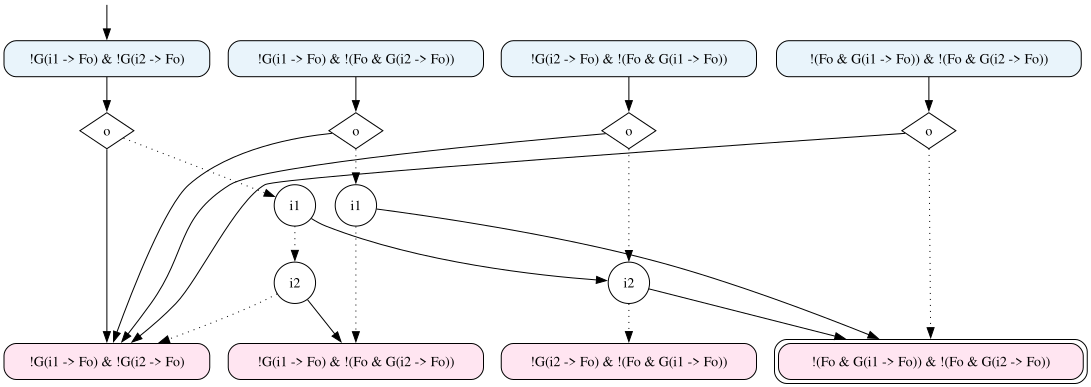

In [65]:
with spot.bdd_dict_preorder("o") as d:
    a = spot.ltlf_to_mtdfa_compose("!G(i1 -> Fo) & !G(i2 -> Fo)", dict=d)
    a.set_controllable_variables(["o"])
display(a)

In [66]:
spot.mtdfa_winning_region(a)

(False, False, False, True)

The above function returns a vector of Boolean indicating for each state whether it wins or not.

Above, the fixpoint decides that only state 3 is winning, because from `[3]`, we can force $o=\top$ to reach an accepting terminal.  The other three states are not winning, because regardless of the value of $o$, some values of $i_1$ or $i_2$ will prevent the automaton from reaching state 3.

Let's look at something a bit more complicated, and compare Moore's and Mealy's semantics.

In [67]:
f = spot.formula("G(i8<->Fo8) & (o9 -> G(Xi9<->o8))")
C = ["o8", "o9"]
UC = ["i8", "i9"]

print("Moore semantics:")
with spot.bdd_dict_preorder(*C) as d:
    a_moore = spot.ltlf_to_mtdfa_compose(f, dict=d)
    a_moore.set_controllable_variables(C)
    display(a_moore.show(labels=False))
    print(spot.mtdfa_winning_region(a_moore))

print("\nMealy semantics:")
with spot.bdd_dict_preorder(*UC) as d:
    a_mealy = spot.ltlf_to_mtdfa_compose(f, dict=d)
    a_mealy.set_controllable_variables(C)
    display(a_mealy.show(labels=False))
    print(spot.mtdfa_winning_region(a_mealy))

Moore semantics:


(False, False, False, False, False, False)

Mealy semantics:


(True, False, False, False, True, False)


Here, the game cannot be won (the specification is unrealizable) with Moore semantics, and only states `0` and `4` are winning with Mealy semantics.   


Note that while the above `spot.mtdfa_winning_region` is checking whether each state is winning, it does too much work our purpose: 
- We want to know if state 0 is winning.
- We only need to check the winning status of states that are reachable from state 0 via **non-accepting terminals**
- When a state is found to be winning, only its predecessors needs to be checked again at the next iteration.

One way to interpret the first two points is to pretend that each accepting terminal has been replaced by an accepting true sink.  The function `mtdfa_restrict_as_game()` will do that rewriting and remove all non-accessible states so we can visualize it.  (Beware that this procedure is renumbering states: you can still look at the LTLf formulas of each state by hovering above their number with your mouse if you have trouble matching those with the previous automata.)

In [68]:
a_moore2 = spot.mtdfa_restrict_as_game(a_moore)
display(a_moore2.show(labels=False))
print(spot.mtdfa_winning_region(a_moore2))

(False, False, False)


In [69]:
a_mealy2 = spot.mtdfa_restrict_as_game(a_mealy)
display(a_mealy2.show(labels=False))
print(spot.mtdfa_winning_region(a_mealy2))

(True, False, False)


The nice thing about this reduced MTDFA game is that it has fewer states, since only non-accepting states need to be represented.  However, we do not really have to build that reduced DFAs to benefit from that, we can simply explore the non-accepting part of the original MTDFA.  This is what `mtdfa_winning_region_lazy` does: instead of computing the winning status of every state, it only computes the winning status for the states that are reachable from state 0 without going through a winning terminal.  (This can be done by hooking the `winterm()` function used in the `is_winning_state()` function shown above to record the non-winning terminals it encounters.)  Additionally, this version will stop as soon is it determinates that state 0 is winning (if state 0 is not winning, or if the algorithm stops when it reaches a fixpoint).  Finally, this lazy version also updates only the predecessors of the states that have been found winning at the previous iteration.

Compare `mtdfa_winning_region` and `mtdfa_winning_region_lazy` on the following:

In [70]:
display(a_mealy.show(labels=False))
print(spot.mtdfa_winning_region(a_mealy))
print(spot.mtdfa_winning_region_lazy(a_mealy))

(True, False, False, False, True, False)
(True, False, False, False, False, False)


While state 4 is actually winning, `mtdfa_winning_region_lazy` does not bother because state 4 cannot be reached from  by a sequence of only non-accepting terminals.  Here `mtdfa_winning_region_lazy` first calls `is_winning_state` on state 0.  `is_winning_state` records (as a side-effect of calling `winterm()`) that the only non-winning terminals state 0 can reach correspond to state 2 and 3.  `is_winning_state` also returns that after ∀∃-quantification, state 0 is already winning, so states 2 and 3 do not even have to be explored.

There is also a variant called `mtdfa_winning_region_lazy3` that works similarly to `mtdfa_winning_region_lazy` but using 3-valued logic.  In that case, the returned vector uses False/True/maybe: False means that the input player has a way to force the game to reach the bddfalse node from that state, True means that the output player has a way to force the game to reach an accepting node from that state, and maybe means that either no player can reach their targets or the lazy algorithm aborted before being able to make a decision for this state.

In [71]:
print(spot.mtdfa_winning_region_lazy3(a_mealy))

(spot.trival(True), spot.trival_maybe(), spot.trival(False), spot.trival(False), spot.trival_maybe(), spot.trival_maybe())


Knowing the winning region actually allows us to reduce the game represented by the MTDFA a bit more: in addition to changing accepting terminal into true, we can also change losing (i.e., non-winning) terminals into false.

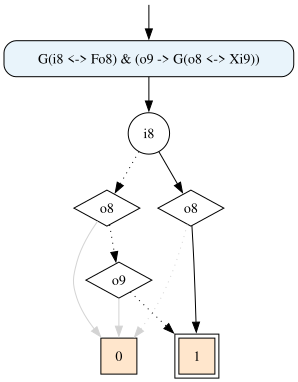

In [72]:
winning_states = spot.mtdfa_winning_region_lazy(a_mealy)
spot.mtdfa_restrict_as_game(a_mealy, winning_states)

This also works with the three-valued variant:

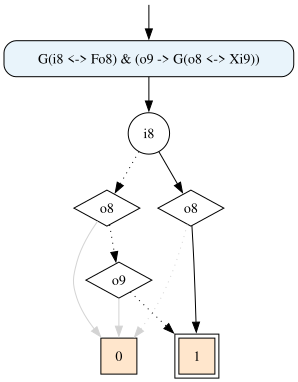

In [73]:
winning_states3 = spot.mtdfa_winning_region_lazy3(a_mealy)
spot.mtdfa_restrict_as_game(a_mealy, winning_states3)

By *chance*, the above is so simple that it is a winning strategy: we can tell because every controllable node has one black arrow (that should be taken) and one gray arrow (that should not be taken).

Let's look at a larger example using Moore semantics to show that this reduction of the game does not always lead to  a strategy:

winning region: (True, True)
          lazy: (True, True)


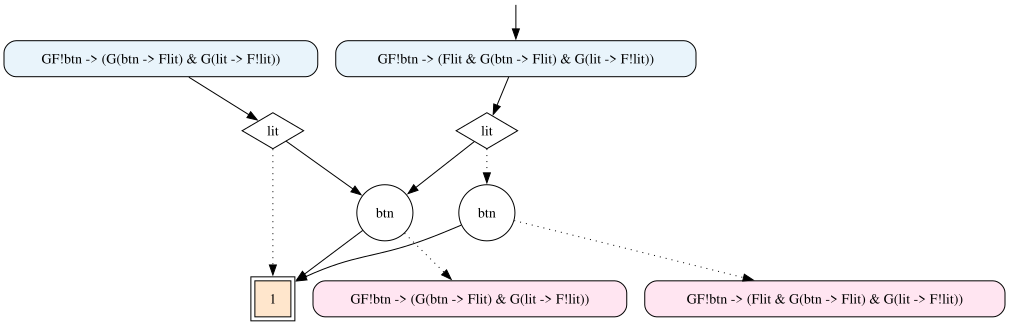

In [74]:
f2 = spot.formula('GF(!btn) -> (G(btn -> Flit) & G(lit -> F!lit) & Flit)')
C2 = ["lit"]
with spot.bdd_dict_preorder(*C2) as d:
    a_moore = spot.ltlf_to_mtdfa_compose(f2, dict=d)
    a_moore.set_controllable_variables(C2)
    display(a_moore.show(labels=True))
    print("winning region:", spot.mtdfa_winning_region(a_moore))
    ws = spot.mtdfa_winning_region_lazy(a_moore)
    print("          lazy:", ws)
    display(spot.mtdfa_restrict_as_game(a_moore, ws))


To describe a winning strategy, we need to select one successful edge for each controllable variable.  We do that by modifying the MTBDD and redirecting the other edge to false.  The implementation of this algorithm is actually very similar to the fixpoint algorithm used by `mtdfa_winning_region_lazy()`.  Instead of `is_winning_state`, the core of the fixpoint loop looks as follows: 

```python
# inputs:
#   b: the MTBDD representing the state to refine
#   C: the set of controllable variable
#   winterm: a function that indicates whether b is a known winning
#            terminal, and that schedule the corresponding state for
#            processing if it is not terminal.
# output: (res, val)
#   res: the rewritten MTBDD
#   val: a value indicating if that state is winning for sure 
# if val is true, each controllable variable in res has a single non-false successor.
def refine_state(b, C, winterm, cache):
    # leaves
    if b == bddtrue: return (b, True)
    if b == bddfalse: return (b, False)
    if is_terminal(b):
        if is_accepting_terminal(b):
            return bddtrue, val   # remap any accepting terminal to bddtrue
        else: 
            return b, winterm(b)  # is this terminal known to be winning?

    # internal nodes
    if b in cache: return cache[b] 
    (rlow, vlow) = refine_state(b.low, C, winterm, cache)
    (rhigh, vhigh) = refine_state(b.high, C, winterm, cache)
    if b.var in C: 
        val = vlow | vhigh  # ∃-quantification
        if val:  # winning existential node: cut one of the two branches
            if vlow:
                rhigh = bddfalse
            else:
                rlow = bddfalse
    else:
        val = wlow & whigh  # ∀-quantification
        if !val and (rlow == bddfalse or rhigh == bddfalse):
            # if one branch of a universal node is false,
            # we can reduce the node to false.
            rlow = rhigh = bddfalse
        # if one child a universal node is bddtrue, we
        # can replace the current node by the other child
        if rlow == bddtrue:
            rlow = rhigh
        elif rhigh == bddtrue:
            rhigh = rlow
    res = bdd_makenode(b.bar, rlow, rhigh)
    cache[b] = (res, val)
    return (res, val)
```

Essentially, this performs the work of `is_winning_state()` in addition to modifying the MTBDD.  There are only four modifications performed: (1) accepting terminals are replaced by `bddtrue`, (2) internal nodes that are both winning representing a controllable variable get one of their successors redirected to false (we keep a branch that is winning, of course), and (3) if a universal node has bddfalse as a child, that node can be replaced by bddfalse, and (4) if a universal node has bddtrie as child, that node can be replaced by the other child.

**TODO?** There should be room for improvement in the above algorithm, because the second recursive call to `refine_state()` can be skipped if `vlow == True` and `b.var in C`.  Implementing this is trickier than it looks,
because the actual implementation is non-recursive and very low-level.  Furthermore, on a few examples where I tried, attempting to remove the second recursive call when possible actually slowed the implementation down without reducing the number of calls to bdd_makenode (either the "saved" branch was cached already, or it needed to be computed later anyway).  So currently I have this optimization disabled.

After applying the above in a fixpoint until state 0 is accepting, here is what we get for the previous example:

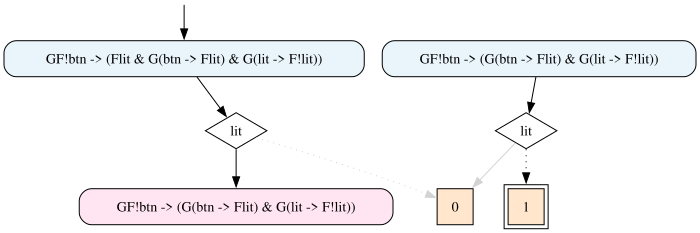

In [75]:
spot.mtdfa_winning_strategy(a_moore, False)

The above tells us that, initially, the controller should emit have `lit=1`, and on the next step it should do `lit=0` regardless of what the environment plays (in fact the controller only need to do `lit=0` if `btn=0`; if `btn=1` the controller is free to do anything, so this includes doing `lit=0`).

Here is the output of `mtdfa_winning_strategy` run on a previous example with Mealy semantics. Note that states that are not winning are mapped to false instead of being removed.  Removing states would require renumbering terminals, so it is cheaper to keep them and set their MTBDD to `bddfalse`.

In [76]:
display(a_mealy2.show(labels=False))
strat = spot.mtdfa_winning_strategy(a_mealy2, False)
display(strat.show(labels=False))

# Building a restricted MTBDD-based DFA for synthesis

Since we do not need to traverse accepting terminals while solving a synthesis propblem, it is actually wasteful to create the full DFA for the original formula.  We can instead instruct `ltlf_to_mtdfa` to replace accepting terminals by `bddtrue` during the construction of the DFA.  This can be done my applying `refine_state` on the output of `tr()` during the construction (just assume that `winterm(s)` is always `False` at this point). Using that `refine_state` function actually has the added advantage of simplifying controllable nodes that can reach `bddtrue`, and simplifying uncontrollable nodes that can reach `bddfalse`, so this helps a lot in reducing the number of states that have to be explored.

Let's see the effect on the following example.  Here is the full translation for the formula $f$ defined earlier.

In [77]:
display(f)
with spot.bdd_dict_preorder(*UC) as d:
    aa = spot.ltlf_to_mtdfa(f, True, True, True, dict=d)
    aa.set_controllable_variables(C)
    display(aa.show(labels=False))

spot.formula("G(i8 <-> Fo8) & (o9 -> G(o8 <-> Xi9))")

The way the original (full) translation works is that it first builds the MTBDD for state 0 using the $tr(f)$ function defined at the top of this notebook, as seen below:

In [78]:
aa.show(state=0, labels=False)

Then it gathers all the states that appear in terminals, i.e., $\{1,2,3,4,5,6\}$, and repeats the process for each state.   However, here, we can see that state 1,4,6 are accepting, so for the purpose of synthesis we can simply replace those by `bddtrue`.   Furthermore, $o8$ and $o9$ are controllable variables, so we can force them to reach always that `bddtrue` leaf.  In the end, we just have `bddfalse` and `bddtrue` as terminals, and we do not need to explore further states.

We can trigger this restricted translation by using `ltlf_to_mtdfa_for_synthesis`, that takes a set `C` of controllable variables.  This function has options, and implement different **node**-based or **state**-based approaches.   Option `state_refine` requests a restricted translation in which states have been refined as described earlier.  The result is not necessarily a strategy: in general, it is a game that must still be solved.

In [79]:
with spot.bdd_dict_preorder(*UC) as d:
    display(spot.ltlf_to_mtdfa_for_synthesis(f, C, approach="state_refine", dict=d).show(labels=False))

This, by chance, is already a strategy. In general we should just expect fewer states that the complete translation.
Also, in this example, the order of o8 and o9 has changed compared to the complete construction.  This is just a side-effect of `ltlf_to_mtdfa_for_synthesis` having to build a table of all output variables before actually starting the translation.

The previous example shows that by refinining *output* nodes to make them point toward `bddtrue`, we avoid constructing many states.   Dually, `refine_state()` can replace any *input* nodes that have a `bddfalse` child by `bddfalse` since such a node is already losing.  This can save the construction of many states as well.  Here is an example.  First, the full translation:

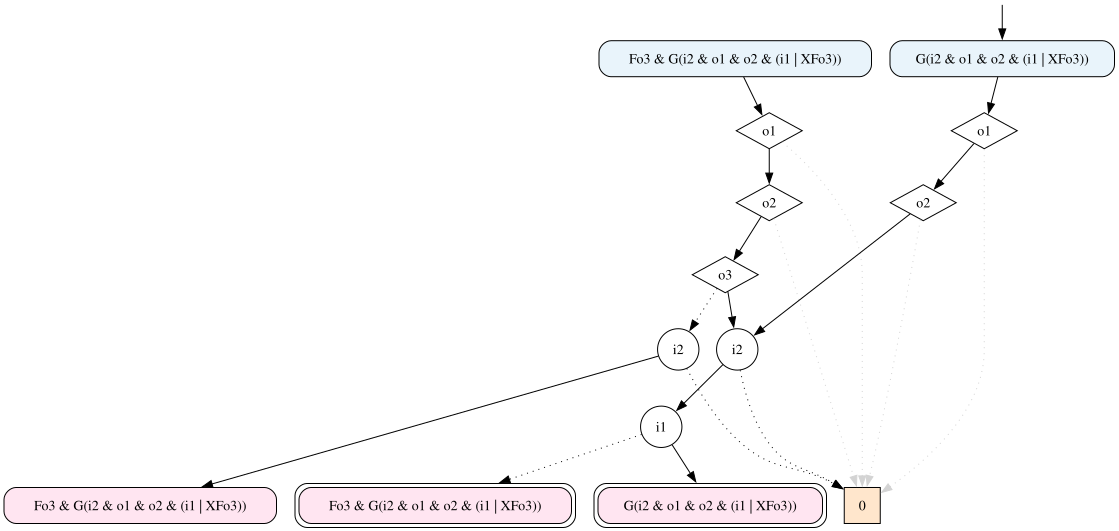

In [80]:
f = spot.formula('G(o1 & o2 & (i1 | XFo3) & i2)')
C = ["o1", "o2", "o3"]
with spot.bdd_dict_preorder(*C) as d:
    aa = spot.ltlf_to_mtdfa(f, True, True, True, dict=d)
    aa.set_controllable_variables(C)
    display(aa)

However, the output nodes labeled by `i2` both have bddfalse as successor, so if we do that during the translation, the initial states simplifies to `bddfalse` and we do not have to construct additional nodes.

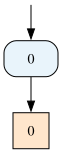

In [81]:
with spot.bdd_dict_preorder(*C) as d:
    aa = spot.ltlf_to_mtdfa_for_synthesis(f, C, approach="state_refine", dict=d)
    display(aa)

`ltlf_to_mtdfa_for_synthesis` implements different approaches.  If you replace `state_refine` by `dfs_node_backprop` or `bfs_node_backprop`, this will build the MTDFA and the backprop graph on-the-fly while solving the game, and it will return a strategy.   Using `dfs_node_backprop` gives the best results, so this is the default.

# Strategy to AIG

We can convert the above strategies into Mealy machines, which in Spot are just TwAs with true acceptance, decorated with a property indicating which are the output propositions.  Then, such a Mealy machine can simply be converted to an And Inverter Graph using Spot's AIG encoder (`spot.mealy_machine_to_aig`).

Spot has no representation for Moore machines.  However, a Moore machine can always be seen as a Mealy machine in which the output signals are only dependent on the input state.  Therefore, this conversion is also OK when the strategy was built with Moore semantics.

In [82]:
print("Mealy strategy")  # the one computed a few cells above
twa1 = spot.mtdfa_strategy_to_mealy(strat)
aig1 = spot.mealy_machine_to_aig(twa1, "isop")
display_inline(strat.show(labels=False),
               twa1.show('.1v'), aig1, per_row=3)

Mealy strategy


In [83]:
print("Moore strategy")
strat2 = spot.mtdfa_winning_strategy(a_moore, True)
twa2 = spot.mtdfa_strategy_to_mealy(strat2)
aig2 = spot.mealy_machine_to_aig(twa2, "isop")
display_inline(strat2.show(labels=False), twa2.show('.1v'), aig2, per_row=3)

Moore strategy


In an AIG computed for a Moore strategy, the output signals only depend on latches, they cannot depend on input signals.  However latches can be updated from input signals.

`spot.mtdfa_strategy_to_mealy` has an option to stutter on acceptance.  I.e., instead of jumping to an accepting sink as shown above (to reflect the fact that after the specification is fulfilled any behavior is ok), it will jump back to he previous state (that's one possible behavior).  Doing so saves one state:

In [84]:
print("Mealy strategy")  # the one computed a few cells above
twa1 = spot.mtdfa_strategy_to_mealy(strat, False, True)
aig1 = spot.mealy_machine_to_aig(twa1, "isop")
display_inline(strat.show(labels=False),
               twa1.show('.1v'), aig1, per_row=3)

Mealy strategy


In [85]:
print("Moore strategy")
strat2 = spot.mtdfa_winning_strategy(a_moore, True)
twa2 = spot.mtdfa_strategy_to_mealy(strat2, False, True)
aig2 = spot.mealy_machine_to_aig(twa2, "isop")
display_inline(strat2.show(labels=False), twa2.show('.1v'), aig2, per_row=3)

Moore strategy
